# ECB Shock Regressions at the Index Level – Thesis-Grade Specification

This notebook estimates index-level (time-series) regressions of Euro\,500 returns on ECB monetary-policy and information shocks, with interactions on an annual aggregate market-duration measure matched to each event with a strict one-year lag. It complements the firm-level cross-sectional regressions in `ECBShocks_Equities_Regressions.ipynb` by asking whether the *aggregate* Euro\,500 reacts more strongly to ECB shocks in years when the market portfolio tilts toward longer-duration stocks.

**Sample:** ECB Governing-Council events from 1999 onward, matched to the value-weighted non-financial Euro\,500 NpD aggregate from the previous calendar year. The full sample contains 309 events. The FcstD-only robustness subsample contains the same 309 events; the yearly FcstD aggregate built with the one-year-lag matching rule covers the full event range.

**Specification highlights**

- Aggregate market duration: value-weighted across non-financial Euro\,500 constituents within a calendar year, standardized to zero mean and unit variance across the yearly panel.
- Strict one-year lag: events in calendar year $y$ use the NpD aggregate from year $y-1$, ensuring the regressor is predetermined.
- Two dependent variables: $R_{0}$ (event-day return) and $R_{0,1}$ (two-day cumulative return).
- HC1 heteroskedasticity-robust standard errors throughout.
- Two model specifications: $M_{1}$ baseline (no controls), $M_{2}$ with year fixed effects.

**Duration measures**

- **Main (NpD):** value-weighted Net Payout Duration, mirroring the firm-level main measure.
- **Robustness only (FcstD):** value-weighted Forecast Duration, reported in a single dedicated section with a separate output table.

**Robustness checks (Sections "Robustness 1–5" + Extension A)**

- R1: Year-over-year changes in NpD market duration ($\Delta$NpD).
- R2: Rolling 5-year window regime regression.
- R3: Alternative regime thresholds (P33/P67 and P25/P75).
- R4: Further-lagged NpD market duration (year $t-2$ instead of $t-1$).
- R5: Aggregate FcstD market duration (alternative duration measure).
- Extension A: Subperiod analysis (Pre/Post GFC, ZLB, COVID).

**Headline result (Model 1, NpD, value-weighted, $R_{0,1}$)**

- Continuous interaction $\text{ShockMP} \times \text{NpD}$: $-0.0315$ ($t = -1.00$). Not statistically significant — consistent with the structural weakness of linear interactions under aggregate duration, discussed in Section 12 (Identification).
- High-minus-Low regime difference (median split): $-0.0832$ ($p = 0.37$); directional but not statistically significant. Significance emerges under tighter thresholds: $-0.1771$ at P33/P67 ($p = 0.04$) and $-0.1833$ at P25/P75 ($p = 0.03$). The dose-response pattern across thresholds is the more informative evidence than any single split.

**Reading guide**

The linear interaction at the index level is mechanically weak: the identifying variation comes from a single time series of aggregate duration that moves only gradually, and the continuous-interaction coefficient is correspondingly imprecise. The regime-split design recovers more of the economic content by comparing average shock sensitivity across high- and low-duration market states. The evidence is consistent with the firm-level duration channel reported in the thesis but, taken in isolation, should be read as suggestive rather than confirmatory: the median split is directional but insignificant, while tighter thresholds (P33/P67, P25/P75) produce significant differences with a monotone dose-response pattern. The remainder of this notebook documents both designs and a sequence of robustness checks.


## 0. Variable Naming (Short Guide)

**Dependent variables (event-window returns)**

- `R_0`: event-day Euro\,500 simple return.
- `R_0_1`: two-day cumulative Euro\,500 return ($1 + r_{0}$ multiplied
  by $1 + r_{1}$).
- `R_m1_1`: three-day window from $-1$ to $+1$ (used for diagnostics).

**Shock variables (Jaroci\'nski–Karadi decomposition)**

- `ShockMP`: monetary policy shock (`MP_median`).
- `ShockInfo`: central bank information shock (`CBI_median`).

**Market-duration variables**

- `market_duration_netpayout`: annual value-weighted aggregate of
  firm-level NpD across non-financial Euro\,500 constituents.
- `market_duration_netpayout_z`: cross-time standardized version of the
  above (zero mean, unit variance over the annual panel).
- `market_duration_fcstd`, `market_duration_fcstd_z`: analogues for
  Forecast Duration, used only in the FcstD robustness section.
- `D_netpayout_yearly_event`: event-level matched value of the annual
  NpD aggregate from the preceding calendar year (one-year lag);
  used in the regime-split and large-shock subsample analyses.

**Sample objects**

- `market_duration_yearly`: panel with one row per calendar year.
- `event_dataset`: full event-level panel (one row per ECB event) with
  the one-year-lagged NpD and FcstD already merged in.
- `event_dataset_yearly`: same as `event_dataset`, retained under this
  alias for downstream regime-analysis code.
- `main_sample`: the subset with non-missing NpD and shocks; used for
  the main regressions.
- `analysis_sample`: the subset used for the regime splits and
  Extension A (drops events with missing yearly NpD match).
- `MP_large_sample`, `Info_large_sample`: subsets restricted to the top
  30% of $|\text{ShockMP}|$ or $|\text{ShockInfo}|$ events, respectively.

**Result objects**

- `results_main`: main regressions on `main_sample` (Models $M_{1}$ and
  $M_{2}$, both return windows, NpD only).
- `results_raw_duration`: same regressions on the unstandardized
  duration column, reported as a robustness diagnostic.
- `results_hac`: same regressions with HAC(1) standard errors.
- `results_large_shocks`: main regressions restricted to the
  large-shock subsample.
- `results_fcstd`: dedicated FcstD robustness regression
  (Robustness 5).
- `regime_results_full`, `regime_results_large_shocks`,
  `regime_differences_full`, `regime_differences_large_shocks`: outputs
  of the high-versus-low duration regime split design.

**LaTeX tables**

- `tab_index_main_npd.tex`: main two-panel table (NpD, $R_{0}$ and
  $R_{0,1}$).
- `tab_index_robustness_summary.tex`: consolidated summary of
  Robustness 1–4.
- `tab_index_fcstd_robustness.tex`: dedicated FcstD robustness table.

All standardisations use sample standard deviation with `ddof=1`.


## 1. Setup and imports

This section defines placeholder file paths, output locations, and flexible column mappings. The notebook is written so that the main variable names can be adjusted in one place before running the full workflow.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis, save_figure as _ps_save_figure

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
set_global_plot_style()

from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR

# ------------------------------------------------------------------
# User inputs: defaults follow the existing project notebooks.
# ------------------------------------------------------------------
path_fcstd_duration = DATA_DIR.parent / "intermediate" / "EQDuration_Fcst.parquet"
path_netpayout_duration = DATA_DIR / "EQDuration_Netpayout.parquet"
path_ecb_shocks = DATA_DIR / "shocks_ecb_mpd_me_d.csv"
path_euro500_returns = DATA_DIR / "euro500_index_returns.parquet"
path_euro500 = DATA_DIR.parent / "intermediate" / "euro500.parquet"
exclude_financials = True

output_dir = BASE_DIR / "tables" / "ECBShocks_Index_Regressions"
output_dir.mkdir(parents=True, exist_ok=True)

NOTEBOOK_GRAPH_DIR = BASE_DIR / "graphs" / "ECBShocks_Index_Regressions"
NOTEBOOK_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str, dpi: int = 150):
    path = NOTEBOOK_GRAPH_DIR / f"{name}.png"
    _ps_save_figure(fig, path, dpi=dpi)

# ------------------------------------------------------------------
# Column mapping candidates: adjust these lists if your files differ.
# The helper functions take the first matching column.
# ------------------------------------------------------------------
DURATION_COMMON = {
    "date_candidates": ["date", "Date", "as_of_date", "obs_date", "effective_date"],
    "quarter_candidates": ["quarter", "Quarter", "quarter_end", "quarter_date"],
    "firm_candidates": ["firm_id", "FirmID", "gvkey", "isin", "ric", "RIC", "Instrument"],
    "mcap_candidates": ["market_cap", "MarketCap", "mcap", "mcap_eur", "ME", "ff_mcap", "weight_base_mcap"],
    "sector_candidates": ["trbc_sector", "TRBC_Sector", "sector", "Sector", "gics_sector", "GICS_sector_name"],
}

FCSTD_CONFIG = {
    "duration_candidates": ["Duration_FcstD", "duration_fcstd"],
    "usable_flag": "pv_fit_poor",   # exclude where pv_fit_poor == True
}

NETPAYOUT_CONFIG = {
    "duration_candidates": ["Duration_NetPayout_trim", "Duration_NetPayout", "Duration_NP_trim", "Duration_NP", "NP_Duration", "duration_np", "netpayout_duration", "duration_netpayout", "NetPayoutDuration", "eq_duration_netpayout"],
}

ECB_CONFIG = {
    "event_date_candidates": ["event_date", "date", "Date", "meeting_date"],
    "shock_mp_candidates": ["MP_median"],
    "shock_info_candidates": ["CBI_median"],
}

INDEX_CONFIG = {
    "date_candidates": ["date", "Date", "trade_date"],
    "price_candidates": ["price", "Price", "close", "Close", "index_level", "IndexLevel", "PX_LAST"],
    "return_candidates": ["market_return_ffmcap_capped80", "market_return_ffmcap", "market_ret_cap80", "index_return", "return", "Return", "simple_return", "ret", "abnormal_return"],
    "log_return_candidates": ["log_return", "LogReturn", "log_ret"],
}

RESULT_COLUMNS = [
    "model_label",
    "duration_variant",
    "duration_weighting",
    "return_window",
    "duration_column",
    "shock_spec",
    "calendar_controls",
    "cov_type",
    "term",
    "coef",
    "std_err",
    "t_stat",
    "p_value",
    "n_obs",
    "r_squared",
]

# ------------------------------------------------------------------
# Sector mapping: firm_id → trbc_sector (from euro500.parquet)
# ------------------------------------------------------------------
_euro500_raw = pd.read_parquet(path_euro500)[['firm_id', 'trbc_sector']].drop_duplicates('firm_id')
SECTOR_MAP = _euro500_raw.set_index('firm_id')['trbc_sector'].astype('string').str.strip().to_dict()
print(f'Sector map loaded: {len(SECTOR_MAP):,} firms '
      f'({(_euro500_raw["trbc_sector"] == "Financials").sum()} Financials)')


Sector map loaded: 1,248 firms (165 Financials)


In [2]:
def first_existing(df, candidates, required=True, label="column"):
    match = next((col for col in candidates if col in df.columns), None)
    if required and match is None:
        raise KeyError(f"Could not find {label}. Tried: {candidates}")
    return match


def load_table(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing input file: {path}")
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".parquet", ".pq"}:
        return pd.read_parquet(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file type for {path}")


def ensure_datetime(series):
    return pd.to_datetime(series, errors="coerce")


def coerce_quarter_end(df, date_col=None, quarter_col=None):
    if quarter_col and quarter_col in df.columns:
        quarter_raw = df[quarter_col]
        quarter_dt = pd.to_datetime(quarter_raw, errors="coerce")
        if quarter_dt.notna().any():
            return quarter_dt.dt.to_period("Q").dt.to_timestamp("Q")
        quarter_period = pd.PeriodIndex(quarter_raw.astype(str), freq="Q")
        return pd.Series(quarter_period.to_timestamp("Q"), index=df.index)
    if date_col and date_col in df.columns:
        return pd.to_datetime(df[date_col], errors="coerce").dt.to_period("Q").dt.to_timestamp("Q")
    raise KeyError("Need either a date column or a quarter column to construct quarter-end dates.")


def standardize_series(series):
    # Sample standard deviation (ddof=1), consistent with the thesis
    # text and with pandas default behaviour. This is the correct choice
    # for finite-sample inference.
    std = series.std(ddof=1)
    if pd.isna(std) or std == 0:
        return pd.Series(np.nan, index=series.index)
    return (series - series.mean()) / std


def significance_stars(p_value):
    if pd.isna(p_value):
        return ""
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.10:
        return "*"
    return ""


def format_coef_tstat(coef, t_stat, p_value, decimals=4):
    if pd.isna(coef):
        return ""
    stars = significance_stars(p_value)
    return f"{coef:.{decimals}f}{stars} ({t_stat:.2f})"


def display_df(df, n=10):
    display(df.head(n) if len(df) > n else df)


## 2. Load firm-level duration data

The notebook expects one file for FcstD (analyst-based) duration and one file for Net-Payout duration. Each file should contain at least a firm identifier, a quarter or date variable, a market-cap variable, and the duration measure itself.


In [3]:
def _standardize_reference_for_mcap(df, common_config=DURATION_COMMON):
    ref = df.copy()
    ref_date_col = first_existing(ref, common_config["date_candidates"], required=False, label="reference date")
    ref_quarter_col = first_existing(ref, common_config["quarter_candidates"], required=False, label="reference quarter")
    ref_firm_col = first_existing(ref, common_config["firm_candidates"], required=True, label="reference firm id")
    ref_mcap_col = first_existing(ref, common_config["mcap_candidates"], required=False, label="reference market cap")
    if ref_mcap_col is None:
        return None
    out = ref.rename(columns={ref_firm_col: "firm_id", ref_mcap_col: "market_cap_ref"}).copy()
    out["quarter_end"] = coerce_quarter_end(out, date_col=ref_date_col, quarter_col=ref_quarter_col)
    out["market_cap_ref"] = pd.to_numeric(out["market_cap_ref"], errors="coerce")
    out = out[["firm_id", "quarter_end", "market_cap_ref"]].dropna(subset=["firm_id", "quarter_end", "market_cap_ref"])
    out = out.sort_values(["firm_id", "quarter_end"]).drop_duplicates(subset=["firm_id", "quarter_end"], keep="last")
    return out


def _standardize_reference_for_sector(df, common_config=DURATION_COMMON):
    ref = df.copy()
    ref_date_col = first_existing(ref, common_config["date_candidates"], required=False, label="reference date")
    ref_quarter_col = first_existing(ref, common_config["quarter_candidates"], required=False, label="reference quarter")
    ref_firm_col = first_existing(ref, common_config["firm_candidates"], required=True, label="reference firm id")
    ref_sector_col = first_existing(ref, common_config["sector_candidates"], required=False, label="reference sector")
    if ref_sector_col is None:
        return None
    out = ref.rename(columns={ref_firm_col: "firm_id", ref_sector_col: "sector_name_ref"}).copy()
    out["quarter_end"] = coerce_quarter_end(out, date_col=ref_date_col, quarter_col=ref_quarter_col)
    out["sector_name_ref"] = out["sector_name_ref"].astype("string").str.strip()
    out = out[["firm_id", "quarter_end", "sector_name_ref"]].dropna(subset=["firm_id", "quarter_end"])
    out = out.sort_values(["firm_id", "quarter_end"]).drop_duplicates(subset=["firm_id", "quarter_end"], keep="last")
    return out


def prepare_duration_frame(df, duration_candidates, label, common_config=DURATION_COMMON, mcap_reference=None):
    df = df.copy()
    date_col = first_existing(df, common_config["date_candidates"], required=False, label=f"{label} date column")
    quarter_col = first_existing(df, common_config["quarter_candidates"], required=False, label=f"{label} quarter column")
    firm_col = first_existing(df, common_config["firm_candidates"], required=True, label=f"{label} firm identifier")
    mcap_col = first_existing(df, common_config["mcap_candidates"], required=False, label=f"{label} market cap")
    sector_col = first_existing(df, common_config["sector_candidates"], required=False, label=f"{label} sector")
    duration_col = first_existing(df, duration_candidates, required=True, label=f"{label} duration")

    rename_map = {firm_col: "firm_id", duration_col: "duration_value"}
    if mcap_col is not None:
        rename_map[mcap_col] = "market_cap"
    if sector_col is not None:
        rename_map[sector_col] = "sector_name"
    out = df.rename(columns=rename_map).copy()
    out["quarter_end"] = coerce_quarter_end(out, date_col=date_col, quarter_col=quarter_col)
    if "market_cap" in out.columns:
        out["market_cap"] = pd.to_numeric(out["market_cap"], errors="coerce")
    else:
        out["market_cap"] = np.nan
    if "sector_name" in out.columns:
        out["sector_name"] = out["sector_name"].astype("string").str.strip()
    else:
        out["sector_name"] = pd.Series(pd.NA, index=out.index, dtype="string")
    out["duration_value"] = pd.to_numeric(out["duration_value"], errors="coerce")

    if out["market_cap"].isna().all() and mcap_reference is not None:
        ref = _standardize_reference_for_mcap(mcap_reference, common_config=common_config)
        if ref is not None:
            out = out.merge(ref, on=["firm_id", "quarter_end"], how="left")
            out["market_cap"] = out["market_cap"].fillna(out["market_cap_ref"])
            out = out.drop(columns=["market_cap_ref"])

    if out["sector_name"].isna().all() and mcap_reference is not None:
        ref_sector = _standardize_reference_for_sector(mcap_reference, common_config=common_config)
        if ref_sector is not None:
            out = out.merge(ref_sector, on=["firm_id", "quarter_end"], how="left")
            out["sector_name"] = out["sector_name"].fillna(out["sector_name_ref"])
            out = out.drop(columns=["sector_name_ref"])

    out = out[["quarter_end", "firm_id", "market_cap", "duration_value", "sector_name"]].dropna(subset=["quarter_end", "firm_id", "market_cap"])
    out["duration_label"] = label
    return out.sort_values(["quarter_end", "firm_id"]).reset_index(drop=True)


raw_euro500 = load_table(path_euro500)
raw_fcstd = load_table(path_fcstd_duration)
path_euro500_daily = DATA_DIR / "euro500_daily_returns.parquet"

# Apply pv_fit_poor filter — only use usable observations
if "pv_fit_poor" in raw_fcstd.columns:
    raw_fcstd = raw_fcstd[~raw_fcstd["pv_fit_poor"].fillna(False)].copy()
    print(f"FcstD after pv_fit_poor filter: {len(raw_fcstd):,} rows")

netpayout_raw = load_table(path_netpayout_duration)

fcstd_firm = prepare_duration_frame(
    raw_fcstd,
    duration_candidates=FCSTD_CONFIG["duration_candidates"],
    label="FcstD",
    common_config=DURATION_COMMON,
    mcap_reference=raw_euro500,
)

netpayout_firm = prepare_duration_frame(
    netpayout_raw,
    NETPAYOUT_CONFIG["duration_candidates"],
    label="NetPayout",
    mcap_reference=raw_fcstd,
)

# ── Merge sector from euro500.parquet (trbc_sector) ──────────────────────────
# The Duration files don't contain sector info, so we fill it from SECTOR_MAP.
for _df in [fcstd_firm, netpayout_firm]:
    _df["sector_name"] = _df["firm_id"].map(SECTOR_MAP).astype("string").str.strip()

# FcstD starts in 2003 — note explicitly
fcstd_start = fcstd_firm["quarter_end"].min()
print(f"FcstD coverage starts: {fcstd_start} (by construction: I/B/E/S CashEPS)")
print(f"FcstD firms: {fcstd_firm['firm_id'].nunique():,}")

print("Loaded firm-level duration data.")
print(f"FcstD rows:      {len(fcstd_firm):,}")
print(f"Net-Payout rows: {len(netpayout_firm):,}")
print(f"Exclude financials in market-duration aggregation: {exclude_financials}")
print(f"FcstD sector coverage: {fcstd_firm['sector_name'].notna().mean():.1%}")
print(f"Net-Payout sector coverage: {netpayout_firm['sector_name'].notna().mean():.1%}")

display_df(fcstd_firm)
display_df(netpayout_firm)

FcstD after pv_fit_poor filter: 9,387 rows
FcstD coverage starts: 1998-12-31 00:00:00 (by construction: I/B/E/S CashEPS)
FcstD firms: 736
Loaded firm-level duration data.
FcstD rows:      9,387
Net-Payout rows: 11,692
Exclude financials in market-duration aggregation: True
FcstD sector coverage: 100.0%
Net-Payout sector coverage: 100.0%


,quarter_end,firm_id,market_cap,duration_value,sector_name,duration_label
0,1998-12-31,FIRM0000001,138569059.780975,15.642538,Consumer Cyclicals,FcstD
1,1998-12-31,FIRM0000002,352801297.226928,31.298416,Industrials,FcstD
2,1998-12-31,FIRM0000003,608489692.860167,26.588638,Industrials,FcstD
3,1998-12-31,FIRM0000004,6612871012.04691,20.474943,Consumer Cyclicals,FcstD
4,1998-12-31,FIRM0000005,1427532695.65364,22.101879,Industrials,FcstD
5,1998-12-31,FIRM0000006,1476235295.66034,22.857123,Basic Materials,FcstD
6,1998-12-31,FIRM0000008,1159667732.63788,17.387268,Basic Materials,FcstD
7,1998-12-31,FIRM0000009,4305243328.21931,16.487641,Consumer Cyclicals,FcstD
8,1998-12-31,FIRM0000017,12934410185.3234,25.028624,Basic Materials,FcstD
9,1998-12-31,FIRM0000019,11046799409.164101,15.065515,Basic Materials,FcstD


,quarter_end,firm_id,market_cap,duration_value,sector_name,duration_label
0,1997-03-31,FIRM0000016,1421928808.82484,NaN,Industrials,NetPayout
1,1997-03-31,FIRM0000063,95191059.782608,NaN,Utilities,NetPayout
2,1997-03-31,FIRM0000118,1364909698.80545,NaN,Consumer Non-Cyclicals,NetPayout
3,1997-03-31,FIRM0000195,525285356.34307,NaN,Industrials,NetPayout
4,1997-03-31,FIRM0000301,581420048.944556,NaN,Consumer Non-Cyclicals,NetPayout
5,1997-03-31,FIRM0000395,853682164.259039,NaN,Consumer Non-Cyclicals,NetPayout
6,1997-03-31,FIRM0000532,6831342.499451,NaN,Industrials,NetPayout
7,1997-03-31,FIRM0000536,19219330.371493,NaN,Consumer Non-Cyclicals,NetPayout
8,1997-03-31,FIRM0000575,166146299.190299,NaN,Consumer Non-Cyclicals,NetPayout
9,1997-06-30,FIRM0000096,88814485.157111,NaN,Consumer Cyclicals,NetPayout


## 3. Construct annual Euro500 market duration series (1-year lag)


In [4]:
def exclude_financial_sector_rows(duration_df):
    df = duration_df.copy()
    if not exclude_financials or "sector_name" not in df.columns:
        return df
    sector = df["sector_name"].astype("string").str.strip().str.casefold()
    is_financial = sector.eq("financials") | sector.str.contains("financial", na=False)
    return df.loc[~is_financial | sector.isna()].copy()


def build_yearly_market_duration(duration_df, value_col_name, n_col_name, coverage_col_name):
    """Aggregate firm-level duration to one observation per calendar year.

    For each firm-year combination, use the last non-missing duration_value
    observed within that calendar year (uses the `quarter_end` field). Then
    take a market-cap–weighted average across all firms in the year.
    """
    df = exclude_financial_sector_rows(duration_df).copy()
    df["year"] = df["quarter_end"].dt.year

    # One observation per firm-year: latest quarter_end in that year
    per_firm_year = (
        df.sort_values(["firm_id", "year", "quarter_end"])
          .groupby(["firm_id", "year"], as_index=False)
          .last()
    )

    # Market-cap weights across firms within each year
    total_mcap = per_firm_year.groupby("year", as_index=False)["market_cap"].sum().rename(
        columns={"market_cap": "total_market_cap"}
    )
    valid = per_firm_year.dropna(subset=["duration_value"]).copy()
    valid_mcap = valid.groupby("year", as_index=False)["market_cap"].sum().rename(
        columns={"market_cap": "covered_market_cap"}
    )
    valid = valid.merge(valid_mcap, on="year", how="left")
    valid["weight"] = valid["market_cap"] / valid["covered_market_cap"]

    grouped = valid.groupby("year")
    weighted = grouped.apply(lambda x: np.average(x["duration_value"], weights=x["market_cap"]))
    n_firms = grouped["firm_id"].nunique()

    out = pd.DataFrame({"year": sorted(per_firm_year["year"].dropna().unique().astype(int))})
    out = out.merge(total_mcap, on="year", how="left")
    out = out.merge(valid_mcap, on="year", how="left")
    out[value_col_name] = out["year"].map(weighted)
    out[n_col_name] = out["year"].map(n_firms)
    out[coverage_col_name] = out["covered_market_cap"] / out["total_market_cap"]
    return out.sort_values("year").reset_index(drop=True)


market_duration_netpayout_year = build_yearly_market_duration(
    exclude_financial_sector_rows(netpayout_firm),
    value_col_name="market_duration_netpayout",
    n_col_name="n_firms_netpayout",
    coverage_col_name="coverage_netpayout",
)

market_duration_fcstd_year = build_yearly_market_duration(
    exclude_financial_sector_rows(fcstd_firm),
    value_col_name="market_duration_fcstd",
    n_col_name="n_firms_fcstd",
    coverage_col_name="coverage_fcstd",
)

# Merge NpD and FcstD yearly panels
market_duration_yearly = market_duration_netpayout_year.merge(
    market_duration_fcstd_year.drop(
        columns=["total_market_cap", "covered_market_cap"], errors="ignore"
    ),
    on="year",
    how="outer",
).sort_values("year").reset_index(drop=True)

# Standardize both
for col in ["market_duration_netpayout", "market_duration_fcstd"]:
    if col in market_duration_yearly.columns:
        market_duration_yearly[f"{col}_z"] = standardize_series(
            market_duration_yearly[col])

print("NpD years:", market_duration_yearly["market_duration_netpayout"].notna().sum())
print("FcstD years:", market_duration_yearly["market_duration_fcstd"].notna().sum())
print("FcstD first year:", int(market_duration_yearly.loc[
    market_duration_yearly["market_duration_fcstd"].notna(), "year"].min()))
print(f"Net-Payout rows used after sector filter: {len(exclude_financial_sector_rows(netpayout_firm)):,}")
print(f"FcstD rows used after sector filter: {len(exclude_financial_sector_rows(fcstd_firm)):,}")

display_df(market_duration_yearly)


NpD years: 28
FcstD years: 27
FcstD first year: 1998
Net-Payout rows used after sector filter: 11,692
FcstD rows used after sector filter: 9,387


,year,total_market_cap,covered_market_cap,market_duration_netpayout,n_firms_netpayout,coverage_netpayout,market_duration_fcstd,n_firms_fcstd,coverage_fcstd,market_duration_netpayout_z,market_duration_fcstd_z
0,1997,840535807624.637573,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN
1,1998,1254667753558.416748,964871283037.639282,27.166243,203.0,0.769025,31.321623,253.0,1.0,1.584542,2.547525
2,1999,2272172405448.774902,2014761540629.788818,30.058233,278.0,0.886712,31.095808,280.0,1.0,3.245054,2.454482
3,2000,2378150441561.849609,2166042688293.22583,27.550159,315.0,0.91081,28.896746,284.0,1.0,1.804977,1.548398
4,2001,1930243870748.935059,1709322825928.123535,26.053296,296.0,0.885548,23.909470,286.0,1.0,0.945514,-0.506518
5,2002,1473419494649.457031,1307579354117.718994,25.533181,289.0,0.887445,26.700346,284.0,1.0,0.646876,0.643412
6,2003,1740224179927.445068,1551970388914.942627,25.488998,322.0,0.891822,21.665690,302.0,1.0,0.621507,-1.431027
7,2004,1984856376718.628906,1899922575015.439941,25.482574,364.0,0.957209,26.438040,311.0,1.0,0.617818,0.535333
8,2005,2424005188229.542969,2256544581509.15332,26.118725,373.0,0.930916,24.782673,327.0,1.0,0.983081,-0.146730
9,2006,3062749272865.046387,2825045897568.300781,24.850867,376.0,0.922389,23.828349,341.0,1.0,0.255107,-0.539942


## 4. Load ECB shock event data

ECB event data should contain one row per event date with a monetary policy surprise and an information shock. The notebook keeps the two shock channels separate throughout, because their economic interpretation can differ.


In [5]:
def prepare_ecb_shocks(df, config=ECB_CONFIG):
    df = df.copy()
    event_date_col = first_existing(df, config["event_date_candidates"], required=True, label="ECB event date")
    shock_mp_col = first_existing(df, config["shock_mp_candidates"], required=True, label="ShockMP")
    shock_info_col = first_existing(df, config["shock_info_candidates"], required=True, label="ShockInfo")

    out = df.rename(columns={
        event_date_col: "event_date",
        shock_mp_col: "ShockMP",
        shock_info_col: "ShockInfo",
    }).copy()
    out["event_date"] = pd.to_datetime(out["event_date"], errors="coerce").dt.normalize()
    out["ShockMP"] = pd.to_numeric(out["ShockMP"], errors="coerce")
    out["ShockInfo"] = pd.to_numeric(out["ShockInfo"], errors="coerce")
    out = out[["event_date", "ShockMP", "ShockInfo"]].dropna().drop_duplicates("event_date").sort_values("event_date").reset_index(drop=True)
    out["event_year"] = out["event_date"].dt.year.astype(int)
    out["abs_shock_scale"] = out[["ShockMP", "ShockInfo"]].abs().max(axis=1)
    return out


ecb_shocks = prepare_ecb_shocks(load_table(path_ecb_shocks))
print(f"ECB events loaded: {len(ecb_shocks):,}")
display_df(ecb_shocks)


ECB events loaded: 312


,event_date,ShockMP,ShockInfo,event_year,abs_shock_scale
0,1999-01-07,0.020578,-0.058123,1999,0.058123
1,1999-01-21,0.008569,-0.004988,1999,0.008569
2,1999-02-18,-0.005565,0.005565,1999,0.005565
3,1999-03-04,-0.003596,0.001670,1999,0.003596
4,1999-03-18,-0.002326,0.001568,1999,0.002326
5,1999-04-08,-0.002429,-0.005027,1999,0.005027
6,1999-04-22,-0.004369,0.001721,1999,0.004369
7,1999-05-06,0.014787,-0.008722,1999,0.014787
8,1999-05-20,0.000644,-0.000644,1999,0.000644
9,1999-06-02,-0.002658,-0.004620,1999,0.004620


## 5. Load Euro500 index return data

The notebook accepts either daily prices or daily returns.

Implementation choice:
- if prices are provided, simple returns and log returns are both computed
- event-window regressions use simple returns by default for direct interpretability
- if a return column is already present, it is used as the baseline daily simple return input


In [6]:
def prepare_index_daily(df, config=INDEX_CONFIG):
    df = df.copy()
    date_col = first_existing(df, config["date_candidates"], required=True, label="index date")
    return_col = first_existing(df, config["return_candidates"], required=False, label="index return")
    price_col = first_existing(df, config["price_candidates"], required=False, label="index price")
    log_return_col = first_existing(df, config["log_return_candidates"], required=False, label="index log return")

    out = df.rename(columns={date_col: "date"}).copy()
    out["date"] = pd.to_datetime(out["date"], errors="coerce").dt.normalize()
    out = out.dropna(subset=["date"]).sort_values("date").drop_duplicates(subset=["date"], keep="last").reset_index(drop=True)

    if price_col:
        out["index_price"] = pd.to_numeric(out[price_col], errors="coerce")
        out["simple_return_from_price"] = out["index_price"].pct_change()
        out["log_return_from_price"] = np.log(out["index_price"]).diff()

    if return_col:
        out["simple_return_input"] = pd.to_numeric(out[return_col], errors="coerce")
    elif "simple_return_from_price" in out.columns:
        out["simple_return_input"] = out["simple_return_from_price"]
    else:
        raise KeyError(f"Need an index return column. Tried: {config['return_candidates']} and price fallbacks.")

    if log_return_col:
        out["log_return_input"] = pd.to_numeric(out[log_return_col], errors="coerce")
    elif "log_return_from_price" in out.columns:
        out["log_return_input"] = out["log_return_from_price"]

    out["lead_return_1"] = out["simple_return_input"].shift(-1)
    out["lag_return_1"] = out["simple_return_input"].shift(1)
    return out


index_daily = prepare_index_daily(load_table(path_euro500_returns))
print(f"Index daily observations loaded: {len(index_daily):,}")
display_df(index_daily[[col for col in index_daily.columns if col in ['date', 'index_price', 'simple_return_input', 'log_return_input', 'lead_return_1', 'lag_return_1']]])


Index daily observations loaded: 7,184


,date,simple_return_input,lead_return_1,lag_return_1
0,1998-01-02,0.027136,0.019075,NaN
1,1998-01-05,0.019075,NaN,0.027136
2,1998-01-06,NaN,-0.004753,0.019075
3,1998-01-07,-0.004753,-0.011034,NaN
4,1998-01-08,-0.011034,-0.007734,-0.004753
5,1998-01-09,-0.007734,-0.017326,-0.011034
6,1998-01-12,-0.017326,0.018747,-0.007734
7,1998-01-13,0.018747,0.008749,-0.017326
8,1998-01-14,0.008749,0.001396,0.018747
9,1998-01-15,0.001396,0.018036,0.008749


## 6. Merge shocks, index returns, and market duration

Two alignment steps matter.

First, event returns are assigned using the first available trading day on or after the ECB event date. This avoids dropping events that fall on non-trading days.

Second, market duration is mapped using the one-year-lagged annual aggregate: each event in calendar year $y$ receives the value-weighted NpD computed from the previous calendar year $y-1$. This makes the no-look-ahead rule fully explicit and eliminates the sampling noise introduced by small off-December fiscal-year-end cohorts in earlier quarterly aggregations.


In [7]:
def build_event_return_dataset(events_df, index_df):
    events = events_df.copy()
    events["event_date"] = pd.to_datetime(events["event_date"])
    index_df = index_df.sort_values("date").copy()

    # Join to find the trade date on/after the event date
    events_sorted = events.sort_values("event_date")
    mapped = pd.merge_asof(
        events_sorted,
        index_df[["date", "simple_return_input", "lead_return_1", "lag_return_1"]].sort_values("date"),
        left_on="event_date",
        right_on="date",
        direction="forward",
    )
    mapped = mapped.rename(columns={"date": "trade_date"})
    mapped["R_0"] = mapped["simple_return_input"]
    mapped["R_0_1"] = (1 + mapped["simple_return_input"]) * (1 + mapped["lead_return_1"]) - 1
    mapped["R_m1_1"] = (1 + mapped["lag_return_1"]) * (1 + mapped["simple_return_input"]) * (1 + mapped["lead_return_1"]) - 1
    return mapped


def map_yearly_market_duration_to_events(events_df, yearly_duration_df, lag_years=1):
    """Attach predetermined NpD / FcstD with a strict k-year lag.

    Events in calendar year y receive the aggregate duration from year y - lag_years.
    """
    events = events_df.copy()
    events["event_year"] = events["event_date"].dt.year
    lookup = yearly_duration_df.copy()
    lookup["event_year"] = lookup["year"] + lag_years
    keep_cols = ["event_year", "market_duration_netpayout", "market_duration_fcstd",
                 "market_duration_netpayout_z", "market_duration_fcstd_z",
                 "n_firms_netpayout", "n_firms_fcstd",
                 "coverage_netpayout", "coverage_fcstd"]
    lookup = lookup[[c for c in keep_cols if c in lookup.columns]]
    merged = events.merge(lookup, on="event_year", how="left")
    merged["matched_year"] = merged["event_year"] - lag_years
    return merged


event_returns = build_event_return_dataset(ecb_shocks, index_daily)
event_dataset = map_yearly_market_duration_to_events(
    event_returns, market_duration_yearly, lag_years=1,
)

mapping_diagnostics = event_dataset[[
    "event_date",
    "trade_date",
    "event_year",
    "matched_year",
    "market_duration_netpayout",
    "market_duration_fcstd",
]].copy()

print("Event-to-year mapping diagnostics (1-year lag):")
display_df(mapping_diagnostics, n=20)


Event-to-year mapping diagnostics (1-year lag):


,event_date,trade_date,event_year,matched_year,market_duration_netpayout,market_duration_fcstd
0,1999-01-07,1999-01-07,1999,1998,27.166243,31.321623
1,1999-01-21,1999-01-21,1999,1998,27.166243,31.321623
2,1999-02-18,1999-02-18,1999,1998,27.166243,31.321623
3,1999-03-04,1999-03-04,1999,1998,27.166243,31.321623
4,1999-03-18,1999-03-18,1999,1998,27.166243,31.321623
5,1999-04-08,1999-04-08,1999,1998,27.166243,31.321623
6,1999-04-22,1999-04-22,1999,1998,27.166243,31.321623
7,1999-05-06,1999-05-06,1999,1998,27.166243,31.321623
8,1999-05-20,1999-05-20,1999,1998,27.166243,31.321623
9,1999-06-02,1999-06-02,1999,1998,27.166243,31.321623


## 7. Define regression samples

The main event-level dataset contains one row per ECB event with shocks, return windows, matched market duration measures, and simple calendar controls. The default interaction regressions standardize duration first so that interaction coefficients are easier to compare across duration concepts.


In [8]:
def add_regression_features(df):
    out = df.copy()
    out["year_str"] = out["event_year"].astype(str)
    out["high_duration_netpayout"] = (out["market_duration_netpayout"] >= out["market_duration_netpayout"].median()).astype(float)
    out["tiny_shock_cutoff"] = out["abs_shock_scale"].quantile(0.20)
    out["large_shock_event"] = out["abs_shock_scale"] > out["tiny_shock_cutoff"]
    return out


event_dataset = add_regression_features(event_dataset)

# Full sample: requires NpD. FcstD is only used in a dedicated robustness section below.
main_sample = event_dataset.dropna(subset=[
    "ShockMP", "ShockInfo", "R_0", "R_0_1",
    "market_duration_netpayout_z",
]).copy()

print(f"Full sample (NpD): {len(main_sample):,} events")

display_df(main_sample[[
    "event_date", "trade_date", "ShockMP", "ShockInfo", "R_0", "R_0_1",
    "market_duration_netpayout", "market_duration_netpayout_z"
]])


Full sample (NpD): 309 events


,event_date,trade_date,ShockMP,ShockInfo,R_0,R_0_1,market_duration_netpayout,market_duration_netpayout_z
0,1999-01-07,1999-01-07,0.020578,-0.058123,-0.017046,-0.016486,27.166243,1.584542
1,1999-01-21,1999-01-21,0.008569,-0.004988,-0.011591,-0.040105,27.166243,1.584542
2,1999-02-18,1999-02-18,-0.005565,0.005565,0.007511,0.019009,27.166243,1.584542
3,1999-03-04,1999-03-04,-0.003596,0.001670,0.008826,0.032139,27.166243,1.584542
4,1999-03-18,1999-03-18,-0.002326,0.001568,-0.004013,0.008730,27.166243,1.584542
5,1999-04-08,1999-04-08,-0.002429,-0.005027,0.004248,0.012410,27.166243,1.584542
6,1999-04-22,1999-04-22,-0.004369,0.001721,0.010945,0.004975,27.166243,1.584542
7,1999-05-06,1999-05-06,0.014787,-0.008722,-0.004374,-0.005946,27.166243,1.584542
8,1999-05-20,1999-05-20,0.000644,-0.000644,0.006949,0.006953,27.166243,1.584542
10,1999-06-17,1999-06-17,0.010342,-0.008552,0.005045,0.009641,27.166243,1.584542


## 8. Estimate main regressions

Baseline specification:

\[
R_t = a + b_1 ShockMP_t + b_2 ShockInfo_t + b_3 (ShockMP_t \\times D_t) + b_4 (ShockInfo_t \\times D_t) + u_t
\]

Expected signs:
- `ShockMP × Duration`: typically negative if a positive monetary policy surprise is a tightening shock that hurts long-duration markets more strongly
- `ShockInfo × Duration`: potentially positive if long-duration or growth-like markets benefit more from improved macroeconomic news


In [9]:
def build_design_matrix(df, y_col, duration_col, include_both_shocks=True, only_shock=None, calendar_controls=False):
    cols = [y_col, duration_col, "ShockMP", "ShockInfo", "event_year"]
    work = df[cols].dropna().copy()
    work["mp_x_d"] = work["ShockMP"] * work[duration_col]
    work["info_x_d"] = work["ShockInfo"] * work[duration_col]

    x_cols = []
    if include_both_shocks:
        x_cols.extend(["ShockMP", "ShockInfo", "mp_x_d", "info_x_d"])
    elif only_shock == "ShockMP":
        x_cols.extend(["ShockMP", "mp_x_d"])
    elif only_shock == "ShockInfo":
        x_cols.extend(["ShockInfo", "info_x_d"])
    else:
        raise ValueError("Invalid shock specification.")

    X = work[x_cols].copy()
    if calendar_controls:
        year_dummies = pd.get_dummies(work["event_year"].astype(int), prefix="year", drop_first=True, dtype=float)
        X = pd.concat([X, year_dummies], axis=1)
    X = sm.add_constant(X, has_constant="add")
    y = work[y_col].astype(float)
    return work, X.astype(float), y


def fit_ols(y, X, cov_type="HC1", cov_lags=1):
    model = sm.OLS(y, X, missing="drop")
    if cov_type.upper() == "HAC":
        return model.fit(cov_type="HAC", cov_kwds={"maxlags": cov_lags})
    return model.fit(cov_type=cov_type)


def collect_terms(result, metadata, requested_terms):
    rows = []
    for term in requested_terms:
        rows.append({
            **metadata,
            "term": term,
            "coef": result.params.get(term, np.nan),
            "std_err": result.bse.get(term, np.nan),
            "t_stat": result.tvalues.get(term, np.nan),
            "p_value": result.pvalues.get(term, np.nan),
            "n_obs": int(result.nobs),
            "r_squared": result.rsquared,
        })
    return rows


def run_model_suite(df, duration_col, duration_variant, duration_weighting, return_window, cov_type="HC1"):
    results = []
    requested_terms = ["ShockMP", "ShockInfo", "mp_x_d", "info_x_d"]

    # Model 1: baseline interaction model with standardized duration.
    work, X, y = build_design_matrix(df, y_col=return_window, duration_col=duration_col, include_both_shocks=True, calendar_controls=False)
    res = fit_ols(y, X, cov_type=cov_type)
    results.extend(collect_terms(res, {
        "model_label": "Model 1",
        "duration_variant": duration_variant,
        "duration_weighting": duration_weighting,
        "return_window": return_window,
        "duration_column": duration_col,
        "shock_spec": "Both shocks",
        "calendar_controls": False,
        "cov_type": cov_type,
    }, requested_terms))

    # Model 2: add year dummies as calendar controls.
    work, X, y = build_design_matrix(df, y_col=return_window, duration_col=duration_col, include_both_shocks=True, calendar_controls=True)
    res = fit_ols(y, X, cov_type=cov_type)
    results.extend(collect_terms(res, {
        "model_label": "Model 2",
        "duration_variant": duration_variant,
        "duration_weighting": duration_weighting,
        "return_window": return_window,
        "duration_column": duration_col,
        "shock_spec": "Both shocks + year FE",
        "calendar_controls": True,
        "cov_type": cov_type,
    }, requested_terms))

    # Model 4A: MP-only interaction.
    work, X, y = build_design_matrix(df, y_col=return_window, duration_col=duration_col, include_both_shocks=False, only_shock="ShockMP", calendar_controls=False)
    res = fit_ols(y, X, cov_type=cov_type)
    results.extend(collect_terms(res, {
        "model_label": "Model 4A",
        "duration_variant": duration_variant,
        "duration_weighting": duration_weighting,
        "return_window": return_window,
        "duration_column": duration_col,
        "shock_spec": "ShockMP only",
        "calendar_controls": False,
        "cov_type": cov_type,
    }, ["ShockMP", "mp_x_d"]))

    # Model 4B: Info-only interaction.
    work, X, y = build_design_matrix(df, y_col=return_window, duration_col=duration_col, include_both_shocks=False, only_shock="ShockInfo", calendar_controls=False)
    res = fit_ols(y, X, cov_type=cov_type)
    results.extend(collect_terms(res, {
        "model_label": "Model 4B",
        "duration_variant": duration_variant,
        "duration_weighting": duration_weighting,
        "return_window": return_window,
        "duration_column": duration_col,
        "shock_spec": "ShockInfo only",
        "calendar_controls": False,
        "cov_type": cov_type,
    }, ["ShockInfo", "info_x_d"]))

    return results


def run_all_main_regressions(df, cov_type="HC1"):
    """NpD-only (value-weighted) main regressions on the NpD sample."""
    result_rows = []
    specs = [
        ("market_duration_netpayout_z", "NpD", "value_weighted"),
    ]
    for duration_col, duration_variant, duration_weighting in specs:
        for return_window in ["R_0", "R_0_1"]:
            subset = df.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
            result_rows.extend(
                run_model_suite(
                    subset,
                    duration_col=duration_col,
                    duration_variant=duration_variant,
                    duration_weighting=duration_weighting,
                    return_window=return_window,
                    cov_type=cov_type,
                )
            )
    return pd.DataFrame(result_rows)


results_main = run_all_main_regressions(main_sample, cov_type="HC1")
# Defensive filter: main regressions are NpD-only by construction.
results_main = results_main[results_main["duration_variant"] == "NpD"].copy()
results_main = results_main[RESULT_COLUMNS].sort_values(["duration_weighting", "duration_variant", "return_window", "model_label", "term"]).reset_index(drop=True)

print("Collected compact regression output rows:")
display_df(results_main, n=20)


Collected compact regression output rows:


,model_label,duration_variant,duration_weighting,return_window,duration_column,shock_spec,calendar_controls,cov_type,term,coef,std_err,t_stat,p_value,n_obs,r_squared
0,Model 1,NpD,value_weighted,R_0,market_duration_netpayout_z,Both shocks,False,HC1,ShockInfo,0.222146,0.033731,6.585835,4.523354e-11,309,0.333486
1,Model 1,NpD,value_weighted,R_0,market_duration_netpayout_z,Both shocks,False,HC1,ShockMP,-0.197780,0.053619,-3.688631,2.254643e-04,309,0.333486
2,Model 1,NpD,value_weighted,R_0,market_duration_netpayout_z,Both shocks,False,HC1,info_x_d,-0.009005,0.023088,-0.390047,6.965015e-01,309,0.333486
3,Model 1,NpD,value_weighted,R_0,market_duration_netpayout_z,Both shocks,False,HC1,mp_x_d,0.004523,0.032295,0.140045,8.886244e-01,309,0.333486
4,Model 2,NpD,value_weighted,R_0,market_duration_netpayout_z,Both shocks + year FE,True,HC1,ShockInfo,0.222540,0.036414,6.111330,9.880397e-10,309,0.394426
5,Model 2,NpD,value_weighted,R_0,market_duration_netpayout_z,Both shocks + year FE,True,HC1,ShockMP,-0.186846,0.047253,-3.954176,7.679872e-05,309,0.394426
6,Model 2,NpD,value_weighted,R_0,market_duration_netpayout_z,Both shocks + year FE,True,HC1,info_x_d,-0.014388,0.023543,-0.611153,5.410983e-01,309,0.394426
7,Model 2,NpD,value_weighted,R_0,market_duration_netpayout_z,Both shocks + year FE,True,HC1,mp_x_d,-0.000389,0.028622,-0.013597,9.891514e-01,309,0.394426
8,Model 4A,NpD,value_weighted,R_0,market_duration_netpayout_z,ShockMP only,False,HC1,ShockMP,-0.200052,0.059668,-3.352754,8.001184e-04,309,0.178128
9,Model 4A,NpD,value_weighted,R_0,market_duration_netpayout_z,ShockMP only,False,HC1,mp_x_d,0.029424,0.036104,0.814987,4.150797e-01,309,0.178128


## 9. Robustness regressions

The robustness section covers:
- equal-weighted market duration instead of value-weighted duration
- alternative return window (`R_0` versus `R_0_1`)
- raw duration instead of z-scored duration
- exclusion of events with very small absolute shocks
- optional high-duration versus low-duration splits
- HAC / Newey-West inference as an additional robustness check


In [10]:
def run_raw_duration_models(df_npd, cov_type="HC1"):
    rows = []
    specs = [
        ("market_duration_netpayout", "NpD", "value_weighted_raw"),
    ]
    for duration_col, duration_variant, duration_weighting in specs:
        for return_window in ["R_0", "R_0_1"]:
            subset = df_npd.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
            rows.extend(run_model_suite(subset, duration_col, duration_variant, duration_weighting, return_window, cov_type=cov_type))
    return pd.DataFrame(rows)


def run_large_shock_models(df_npd, cov_type="HC1"):
    filtered_npd = df_npd[df_npd["large_shock_event"]].copy()
    out = run_all_main_regressions(filtered_npd, cov_type=cov_type)
    out["model_label"] = out["model_label"] + " | large shocks"
    return out


def run_hac_models(df_npd, maxlags=1):
    rows = []
    specs = [
        ("market_duration_netpayout_z", "NpD", "value_weighted"),
    ]
    for duration_col, duration_variant, duration_weighting in specs:
        for return_window in ["R_0", "R_0_1"]:
            subset = df_npd.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
            rows.extend(run_model_suite(subset, duration_col, duration_variant, duration_weighting, return_window, cov_type="HAC"))
    return pd.DataFrame(rows)


def high_low_duration_split(df, duration_col, duration_variant, return_window="R_0_1"):
    subset = df.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
    median_value = subset[duration_col].median()
    subset["duration_group"] = np.where(subset[duration_col] >= median_value, "High duration", "Low duration")

    rows = []
    for group_name, part in subset.groupby("duration_group"):
        work, X, y = build_design_matrix(part, y_col=return_window, duration_col=duration_col, include_both_shocks=False, only_shock="ShockMP", calendar_controls=False)
        res = fit_ols(y, X, cov_type="HC1")
        rows.append({
            "duration_variant": duration_variant,
            "return_window": return_window,
            "group": group_name,
            "coef_ShockMP": res.params.get("ShockMP", np.nan),
            "t_ShockMP": res.tvalues.get("ShockMP", np.nan),
            "coef_ShockMP_x_D": res.params.get("mp_x_d", np.nan),
            "t_ShockMP_x_D": res.tvalues.get("mp_x_d", np.nan),
            "n_obs": int(res.nobs),
        })
    return pd.DataFrame(rows)


results_raw_duration = run_raw_duration_models(main_sample, cov_type="HC1")
results_large_shocks = run_large_shock_models(main_sample, cov_type="HC1")
results_hac          = run_hac_models(main_sample, maxlags=1)

split_netpayout = high_low_duration_split(main_sample, "market_duration_netpayout_z", "NpD")
duration_split_table = split_netpayout.copy()

print("High-vs-low duration split diagnostics:")
display_df(duration_split_table, n=20)


High-vs-low duration split diagnostics:


,duration_variant,return_window,group,coef_ShockMP,t_ShockMP,coef_ShockMP_x_D,t_ShockMP_x_D,n_obs
0,NpD,R_0_1,High duration,-0.246006,-3.105477,0.033119,0.732645,159
1,NpD,R_0_1,Low duration,-0.479103,-2.347769,-0.374166,-1.201205,150


## 10. Output tables

The notebook builds compact tables rather than printing full `statsmodels` summaries. This keeps the regression output thesis-friendly and easy to compare across return windows and duration concepts.


In [11]:
def pivot_main_table(results_df, weighting_filter, model_label="Model 1"):
    subset = results_df[(results_df["duration_weighting"] == weighting_filter) & (results_df["model_label"] == model_label)].copy()
    if subset.empty:
        return pd.DataFrame()

    base = subset[["duration_variant", "return_window", "n_obs", "r_squared"]].drop_duplicates()
    for source_term, col_name in [
        ("ShockMP", "coef(ShockMP)"),
        ("mp_x_d", "coef(ShockMP x D)"),
        ("ShockInfo", "coef(ShockInfo)"),
        ("info_x_d", "coef(ShockInfo x D)"),
    ]:
        term_slice = subset[subset["term"] == source_term][["duration_variant", "return_window", "coef", "t_stat", "p_value"]].copy()
        rename_map = {"coef": col_name}
        if source_term == "mp_x_d":
            rename_map.update({"t_stat": "t-stat MP x D", "p_value": "p-value MP x D"})
        if source_term == "info_x_d":
            rename_map.update({"t_stat": "t-stat Info x D", "p_value": "p-value Info x D"})
        term_slice = term_slice.rename(columns=rename_map)
        base = base.merge(term_slice, on=["duration_variant", "return_window"], how="left")

    return base.rename(columns={
        "duration_variant": "Duration measure",
        "return_window": "Return window",
        "n_obs": "N",
        "r_squared": "R2",
    }).sort_values(["Duration measure", "Return window"]).reset_index(drop=True)


def build_reader_table(results_df, weighting_filter, model_label="Model 1"):
    subset = results_df[(results_df["duration_weighting"] == weighting_filter) & (results_df["model_label"] == model_label)].copy()
    if subset.empty:
        return pd.DataFrame()
    subset["formatted"] = subset.apply(lambda row: format_coef_tstat(row["coef"], row["t_stat"], row["p_value"]), axis=1)
    reader = subset.pivot_table(
        index=["duration_variant", "return_window"],
        columns="term",
        values="formatted",
        aggfunc="first",
    ).reset_index()
    return reader.rename(columns={
        "duration_variant": "Duration measure",
        "return_window": "Return window",
        "ShockMP": "ShockMP",
        "mp_x_d": "ShockMP x D",
        "ShockInfo": "ShockInfo",
        "info_x_d": "ShockInfo x D",
    }).sort_values(["Duration measure", "Return window"]).reset_index(drop=True)


# ── LaTeX helpers (aligned with Equities notebook) ───────────────────────────

def _tex_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return r"$^{***}$"
    if p < 0.05:
        return r"$^{**}$"
    if p < 0.10:
        return r"$^{*}$"
    return ""


_MODEL_ORDER = ["Model 1", "Model 2"]

_CTRL_MATRIX_INDEX = {
    r"Year fixed effects": {
        "Model 1": "No",
        "Model 2": "Yes",
    },
}

_COL_SHORT = {
    "Model 1": "M1",
    "Model 2": "M2",
}


def _build_latex_stargazer_index(results_df, panels, title, notes, label,
                                 controls_footer=True, outpath=None):
    """Build a stargazer-style table with M1/M2 as columns.

    panels: list of (panel_label, filter_dict, interaction_label) tuples.
    Each panel shows: ShockMP, ShockMP x D, ShockInfo, ShockInfo x D, N, R2.
    """
    _df = results_df.copy()
    _specs = [s for s in _MODEL_ORDER if s in _df["model_label"].values]
    if not _specs:
        print(f"[{label}] no specifications available.")
        return ""

    def _row_coefs(sub, term_name, row_label):
        cells = [row_label]
        for spec in _specs:
            r = sub[(sub["model_label"] == spec) & (sub["term"] == term_name)]
            if r.empty:
                cells.append("")
                continue
            c = r["coef"].iloc[0]
            s = r["std_err"].iloc[0]
            p = r["p_value"].iloc[0]
            if pd.notna(c) and c >= 0:
                coef_str = r"$\phantom{-}" + f"{c:.4f}" + r"$" + _tex_stars(p)
            else:
                coef_str = f"${c:.4f}$" + _tex_stars(p)
            se_str = f"~$({s:.4f})$" if pd.notna(s) else ""
            cells.append(coef_str + se_str)
        return " & ".join(cells) + r" \\"

    def _row_stat(sub, stat_col, row_label, fmt):
        cells = [row_label]
        for spec in _specs:
            r = sub[sub["model_label"] == spec]
            if r.empty:
                cells.append("")
            else:
                val = r[stat_col].iloc[0]
                cells.append("" if pd.isna(val) else fmt.format(val))
        return " & ".join(cells) + r" \\"

    ncols = len(_specs)
    L = []
    L.append(r"\begin{table}[htbp]")
    L.append(r"\centering\small")
    L.append(r"\caption{\textsc{" + title + r"}}")
    L.append(r"\label{tab:" + label + r"}")
    L.append(r"\begin{tabular}{l" + "c" * ncols + r"}")
    L.append(r"\toprule")
    L.append(" & " + " & ".join([f"({i+1})" for i in range(ncols)]) + r" \\")
    L.append(" & " + " & ".join([_COL_SHORT.get(s, s) for s in _specs]) + r" \\")
    L.append(r"\midrule")

    panel_letters = "ABCDEFGHIJ"
    for idx, (panel_label, filt, interaction_label) in enumerate(panels):
        letter = panel_letters[idx]
        sub = _df.copy()
        for col, val in filt.items():
            sub = sub[sub[col] == val]
        L.append(r"\multicolumn{" + str(1 + ncols) + r"}{l}{"
                 + r"\textit{Panel " + letter + r": " + panel_label + r"}} \\")

        for term_name, term_label in [
            ("ShockMP", "ShockMP"),
            ("mp_x_d", r"ShockMP $\times$ " + interaction_label),
            ("ShockInfo", "ShockInfo"),
            ("info_x_d", r"ShockInfo $\times$ " + interaction_label),
        ]:
            L.append(_row_coefs(sub, term_name, term_label))

        L.append(_row_stat(sub, "n_obs", r"Observations", "{:,.0f}"))
        L.append(_row_stat(sub, "r_squared", r"$R^{2}$", "${:.3f}$"))
        if idx < len(panels) - 1 or controls_footer:
            L.append(r"\midrule")

    if controls_footer:
        L.append(r"\multicolumn{" + str(1 + ncols) + r"}{l}{"
                 + r"\textit{Controls and fixed effects}} \\")
        for ctrl_label, ctrl_map in _CTRL_MATRIX_INDEX.items():
            cells = [ctrl_label]
            for spec in _specs:
                cells.append(ctrl_map.get(spec, ""))
            L.append(" & ".join(cells) + r" \\")

    L.append(r"\bottomrule")
    L.append(r"\end{tabular}")
    L.append("")
    L.append(r"\vspace{4pt}")
    L.append(r"\begin{minipage}{\textwidth}")
    L.append(r"\footnotesize")
    L.append(r"\textit{Notes.} " + notes)
    L.append(r"\end{minipage}")
    L.append(r"\end{table}")

    _latex = "\n".join(L)
    if outpath is not None:
        Path(outpath).write_text(_latex, encoding="utf-8")
        print(f"Saved: {outpath}")
    return _latex


# ── Build display tables ─────────────────────────────────────────────────────

TABLE_1 = pivot_main_table(results_main, weighting_filter="value_weighted", model_label="Model 1")
TABLE_3 = build_reader_table(results_main, weighting_filter="value_weighted", model_label="Model 1")

print("TABLE 1: Main index regressions using value-weighted NpD")
display(TABLE_1)
print("TABLE 3: Reader table with compact coefficient formatting")
display(TABLE_3)

# ── LaTeX: Main results (NpD, value-weighted) ────────────────────────────────

_title_main = r"Index-Level Duration and ECB Monetary Policy Shocks"
_notes_main = (
    r"Market-duration is the value-weighted average of firm-level Net Payout "
    r"Duration (NpD) across non-financial Euro\,500 constituents, standardised "
    r"to zero mean and unit variance. ShockMP is the ECB monetary policy "
    r"surprise (\texttt{MP\_median}) and ShockInfo the central bank "
    r"information shock (\texttt{CBI\_median}), both from the "
    r"Jaroci\'nski--Karadi decomposition of the ECB MPD "
    r"\citep{jarocinski2020deconstructing}. "
    r"Heteroskedasticity-robust (HC1) standard errors in parentheses. "
    r"$^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$."
)
_tex_main = _build_latex_stargazer_index(
    results_main[results_main["duration_weighting"] == "value_weighted"],
    panels=[
        (r"Event-day return~$R_{0}$",
         {"duration_variant": "NpD", "return_window": "R_0"},
         "NpD"),
        (r"Two-day cumulative return~$R_{0,1}$",
         {"duration_variant": "NpD", "return_window": "R_0_1"},
         "NpD"),
    ],
    title=_title_main,
    notes=_notes_main,
    label="index_main_npd",
    outpath=output_dir / "tab_index_main_npd.tex",
)

print()
print("--- Preview: tab_index_main_npd.tex (first 1500 chars) ---")
print(_tex_main[:1500])


TABLE 1: Main index regressions using value-weighted NpD


,Duration measure,Return window,N,R2,coef(ShockMP),t_stat_x,p_value_x,coef(ShockMP x D),t-stat MP x D,p-value MP x D,coef(ShockInfo),t_stat_y,p_value_y,coef(ShockInfo x D),t-stat Info x D,p-value Info x D
0,NpD,R_0,309,0.333486,-0.19778,-3.688631,0.000225,0.004523,0.140045,0.888624,0.222146,6.585835,4.523354e-11,-0.009005,-0.390047,0.696501
1,NpD,R_0_1,309,0.226811,-0.20973,-4.112660,0.000039,-0.025934,-0.750001,0.453254,0.253021,5.791806,6.963336e-09,0.013448,0.435396,0.663275


TABLE 3: Reader table with compact coefficient formatting


term,Duration measure,Return window,ShockInfo,ShockMP,ShockInfo x D,ShockMP x D
0,NpD,R_0,0.2221*** (6.59),-0.1978*** (-3.69),-0.0090 (-0.39),0.0045 (0.14)
1,NpD,R_0_1,0.2530*** (5.79),-0.2097*** (-4.11),0.0134 (0.44),-0.0259 (-0.75)


Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/ECBShocks_Index_Regressions/tab_index_main_npd.tex

--- Preview: tab_index_main_npd.tex (first 1500 chars) ---
\begin{table}[htbp]
\centering\small
\caption{\textsc{Index-Level Duration and ECB Monetary Policy Shocks}}
\label{tab:index_main_npd}
\begin{tabular}{lcc}
\toprule
 & (1) & (2) \\
 & M1 & M2 \\
\midrule
\multicolumn{3}{l}{\textit{Panel A: Event-day return~$R_{0}$}} \\
ShockMP & $-0.1978$$^{***}$~$(0.0536)$ & $-0.1868$$^{***}$~$(0.0473)$ \\
ShockMP $\times$ NpD & $\phantom{-}0.0045$~$(0.0323)$ & $-0.0004$~$(0.0286)$ \\
ShockInfo & $\phantom{-}0.2221$$^{***}$~$(0.0337)$ & $\phantom{-}0.2225$$^{***}$~$(0.0364)$ \\
ShockInfo $\times$ NpD & $-0.0090$~$(0.0231)$ & $-0.0144$~$(0.0235)$ \\
Observations & 309 & 309 \\
$R^{2}$ & $0.333$ & $0.394$ \\
\midrule
\multicolumn{3}{l}{\textit{Panel B: Two-day cumulative return~$R_{0,1}$}} \\
ShockMP & $-0.2097$$^{***}$~$(0.0510)$ & $-0.1914$$^

## 11. Plots

The plots focus on interpretation rather than styling. The main visual goal is to compare the two market-duration series and summarize how the interaction coefficients behave across specifications.


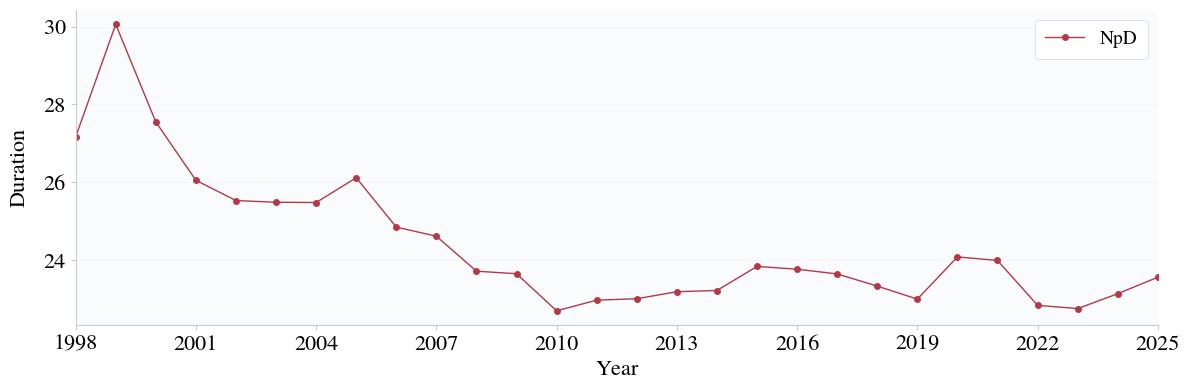

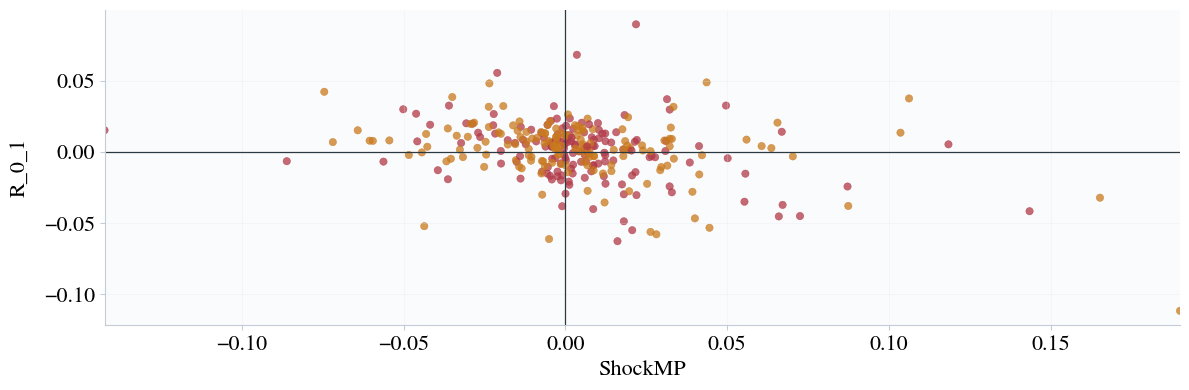

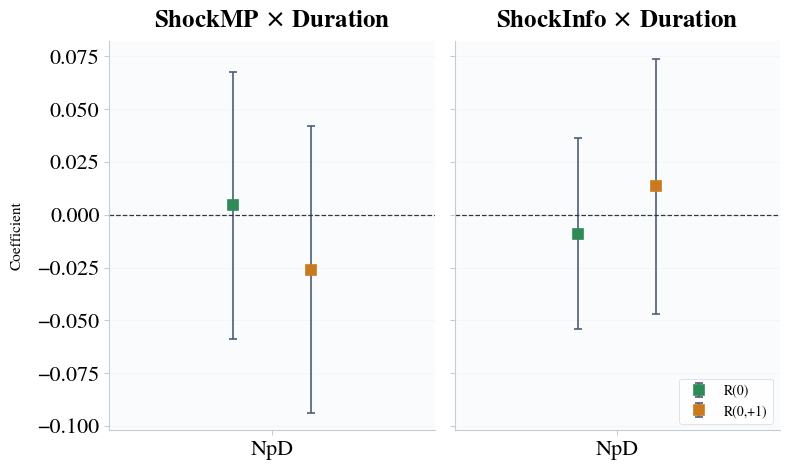

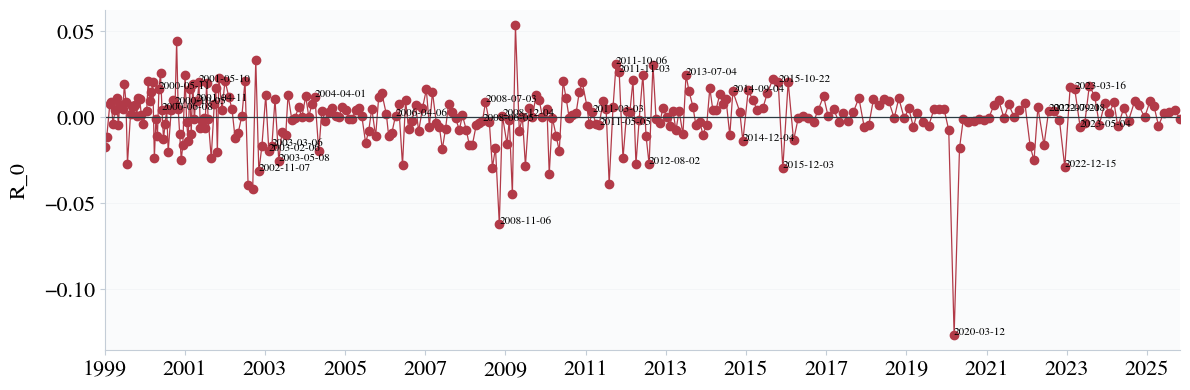

In [12]:
def coefficient_plot_data(results_df):
    # All rows are value-weighted NpD in the main results; filter kept as no-op.
    subset = results_df[(results_df["model_label"] == "Model 1") & (results_df["duration_weighting"] == "value_weighted")].copy()
    subset = subset[subset["term"].isin(["mp_x_d", "info_x_d"])].copy()
    subset["label"] = subset["duration_variant"] + " | " + subset["return_window"] + " | " + subset["term"]
    subset["ci_low"] = subset["coef"] - 1.96 * subset["std_err"]
    subset["ci_high"] = subset["coef"] + 1.96 * subset["std_err"]
    return subset.sort_values(["term", "return_window"]).reset_index(drop=True)


# --- Duration color/marker conventions (consistent with firm-level notebook) ---
_DUR_COLORS = {"NpD": COLORS["accent"]}
_DUR_MARKERS = {"NpD": "s"}

# --- Depvar color conventions (consistent with firm-level notebook) ----------
_DEP_COLORS = {
    "R_0":   COLORS["green"],
    "R_0_1": COLORS["orange"],
}
_DEP_LABELS = {
    "R_0":   "R(0)",
    "R_0_1": "R(0,+1)",
}

# --- Time series plot: NpD only (annual) ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    market_duration_yearly["year"],
    market_duration_yearly["market_duration_netpayout"],
    label="NpD",
    color=_DUR_COLORS["NpD"],
    marker="o", markersize=4,
)
ax.set_xlabel("Year")
ax.set_ylabel("Duration")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
style_axes(ax, grid_axis="y", grid_alpha=0.25)
style_legend(ax, loc="best")
fig.tight_layout()
save_figure(fig, "plot_market_duration_timeseries", dpi=300)
plt.show()

# --- Scatter plot: NpD as coloring variable ---
fig, ax = plt.subplots(figsize=(12, 4))
scatter_df = main_sample.dropna(subset=["ShockMP", "R_0_1", "market_duration_netpayout_z"]).copy()
colors = np.where(
    scatter_df["market_duration_netpayout_z"] >= scatter_df["market_duration_netpayout_z"].median(),
    _DUR_COLORS["NpD"],
    COLORS["orange"],
)
ax.scatter(scatter_df["ShockMP"], scatter_df["R_0_1"], c=colors, alpha=0.75, s=28)
ax.axhline(0, color=COLORS["reference"], linewidth=0.9)
ax.axvline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_xlabel("ShockMP")
ax.set_ylabel("R_0_1")
style_axes(ax, grid_axis="both", grid_alpha=0.25)
fig.tight_layout()
save_figure(fig, "plot_scatter_shockmp_r01", dpi=300)
plt.show()

# --- Coefficient plot: 1x2 layout (ShockMP | ShockInfo), NpD only ----------
_shock_cfg = [
    ("ShockMP",   "mp_x_d"),
    ("ShockInfo", "info_x_d"),
]
_dur_avail = ["NpD"]
_dep_cfg = [
    ("R_0",   "R(0)",    COLORS["green"],  -0.12),
    ("R_0_1", "R(0,+1)", COLORS["orange"], +0.12),
]

fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

for ax_idx, (shock_label, shock_term) in enumerate(_shock_cfg):
    ax = axes[ax_idx]
    _x = np.arange(len(_dur_avail))

    for dep_var, dep_label, dep_color, shift in _dep_cfg:
        vals, errs, ps = [], [], []
        for dur in _dur_avail:
            r = results_main[
                (results_main["model_label"] == "Model 1") &
                (results_main["duration_weighting"] == "value_weighted") &
                (results_main["duration_variant"] == dur) &
                (results_main["return_window"] == dep_var) &
                (results_main["term"] == shock_term)
            ]
            vals.append(float(r["coef"].iloc[0]) if not r.empty else np.nan)
            errs.append(1.96 * float(r["std_err"].iloc[0]) if not r.empty else np.nan)
            ps.append(float(r["p_value"].iloc[0]) if not r.empty else np.nan)

        for ix, dur in enumerate(_dur_avail):
            m = _DUR_MARKERS.get(dur, "o")
            ax.errorbar(
                [_x[ix] + shift], [vals[ix]], yerr=[errs[ix]],
                fmt=m, color=dep_color, markersize=7,
                markerfacecolor=dep_color,
                markeredgecolor=dep_color, markeredgewidth=1.2,
                ecolor=COLORS["neutral"],
                capsize=3, capthick=1.2, linewidth=1.2,
                label=dep_label if ix == 0 else None,
            )

        for ix, (v, pv, e) in enumerate(zip(vals, ps, errs)):
            _star = significance_stars(pv)
            if _star and not np.isnan(v):
                y_off = v + e + abs(v) * 0.05 if v >= 0 else v - e - abs(v) * 0.05
                ax.text(_x[ix] + shift, y_off, _star, ha="center",
                        va="bottom" if v >= 0 else "top", fontsize=10,
                        color=dep_color, fontweight="bold")

    ax.axhline(0, color=COLORS["reference"], linewidth=0.9, linestyle="--")
    ax.set_xticks(_x)
    ax.set_xticklabels(_dur_avail, fontsize=11)
    ax.set_xlim(-0.5, len(_x) - 0.5)
    ax.set_title(f"{shock_label} $\\times$ Duration", fontsize=12, fontweight="bold")
    if ax_idx == 0:
        ax.set_ylabel("Coefficient", fontsize=11)
    style_axes(ax, grid_axis="y", grid_alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.95])
_handles, _labels = axes[0].get_legend_handles_labels()
if _handles:
    axes[1].legend(_handles, _labels, loc="lower right",
                   ncol=1, frameon=True, fontsize=10)
save_figure(fig, "plot_interaction_coefficients", dpi=300)
plt.show()

# --- Event returns over time ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(main_sample["event_date"], main_sample["R_0"], marker="o", linestyle="-", linewidth=0.9, color=COLORS["accent"])
shock_cutoff = main_sample["ShockMP"].abs().quantile(0.9)
for _, row in main_sample.iterrows():
    if abs(row["ShockMP"]) >= shock_cutoff:
        ax.annotate(row["event_date"].strftime("%Y-%m-%d"), (row["event_date"], row["R_0"]), fontsize=8)
ax.axhline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_xlabel("Event date")
ax.set_ylabel("R_0")
style_axes(ax, grid_axis="y", grid_alpha=0.25)
style_time_axis(
    ax,
    x_min=main_sample["event_date"].min(),
    x_max=main_sample["event_date"].max(),
    x_ticks=main_sample["event_date"],
    date_fmt="%Y",
)
fig.tight_layout()
save_figure(fig, "plot_event_returns_over_time", dpi=300)
plt.show()


## 12. Identification and Methodological Notes

The index-level design differs in two ways from the firm-level cross-sectional design used in `ECBShocks_Equities_Regressions.ipynb`, and these differences shape how the results should be read.

**Source of identifying variation.** At the firm level, the $\text{ShockMP} \times \text{NpD}$ coefficient is identified from *cross-firm differences* in NpD within the same event date — the event fixed effects in Model 4 absorb everything that is common across firms on a given day, so the interaction is purely cross-sectional. At the index level, by contrast, there is only one observation per event date (the Euro\,500 return), so the interaction is identified from *year-to-year variation* in aggregate market duration across events. Aggregate market duration moves only gradually: in the annual panel, consecutive observations differ by less than one standard deviation in most years. The continuous interaction therefore has substantially less identifying power at the index level than at the firm level, and the t-statistics are correspondingly smaller. This is a structural feature of the aggregation, not a sign of a missing channel.

**The regime split design.** To work around this loss of power, the notebook complements the linear interaction with a discrete regime split: events are partitioned into a high-duration regime (above the sample median annual NpD aggregate) and a low-duration regime (below the median), and the baseline shock regression is estimated separately within each regime. The High-minus-Low difference in the $\text{ShockMP}$ coefficient is the simpler statistic of interest: does the Euro\,500 react differently to a monetary-policy surprise when the market is in a long-duration state? This is the design that produces the headline result reported in the thesis.

**Why value-weighted, not equal-weighted.** Aggregate market duration is constructed as a value-weighted average across non-financial Euro\,500 constituents. This is the appropriate weighting because the regression explains the *index* return, which is itself a value-weighted aggregate. An equal-weighted aggregation would mis-measure the duration exposure of the marginal euro invested in the Euro\,500.

**Why annual aggregation.** Firm-level NpD observations are concentrated at fiscal year-ends (mostly December, with a small non-December cohort), so a quarterly aggregation delivers a noisy mix of well-covered Q4 quarters and small-sample off-December quarters. Aggregating all within-year firm-year observations into a single annual value-weighted mean eliminates this sampling artefact and produces a smooth time series in which year-over-year movements reflect genuine shifts in the aggregate composition of the Euro\,500.

**Pre-event matching (previous-calendar-year rule).** Each ECB event in calendar year $y$ is matched to the value-weighted NpD aggregate computed over calendar year $y - 1$. This is implemented in `map_yearly_market_duration_to_events` in Cell 14 by setting `event_year = year + 1` in the lookup table. The matched year is stored in the column `matched_year` and the event-level column `D_netpayout_yearly_event` carries the matched duration value.

This rule is predetermined by construction (the regressor observation is fully realised before the event window opens), but the effective calendar distance between regressor and event varies within the year: an event in January is matched to an aggregate from 12 to 24 months before, and an event in December is matched to an aggregate from essentially 0 to 12 months before. This within-year heterogeneity is innocuous for the linear interaction and for the regime split, since both designs are identified from *between-year* variation in the aggregate and treat all events within a calendar year symmetrically. It does mean that the standard "lag" language should be read as "matched to the previous calendar year's aggregate" rather than as a fixed-month offset.

**Standard errors.** All baseline regressions use HC1 heteroskedasticity-robust standard errors. HAC(1) standard errors are also reported as a robustness diagnostic. Because the NpD regressor changes only once per calendar year, events within the same year share an identical regressor value, and the residuals within a year may exhibit autocorrelation that HC1 does not account for. Reassuringly, HC1 and HAC(1) standard errors produce very similar point estimates and t-statistics in the current sample; the HAC(1) row is retained as a belt-and-braces check rather than as the preferred inference.


## 12A. Additional Identification Checks

The next sections strengthen the market-level duration analysis in two ways. First, the weak linear interaction design is complemented with a high-versus-low duration regime split based on the annual NpD aggregate (one-year lag). Second, the same baseline and regime specifications are re-estimated on large-shock subsamples where identification is strongest.


### Annual Market Duration (1-year lag)

The event-level `market_duration_netpayout` column already carries the aggregate NpD from calendar year `event_year - 1`. The next cell creates a passthrough alias so that the regime-split and subperiod code can use a single event-level column `D_netpayout_yearly_event`.


In [13]:
# With the yearly design there is no monthly interpolation: every ECB event in
# calendar year y receives the aggregate NpD from year y-1. We expose a single
# event-level column `D_netpayout_yearly_event` (value-weighted NpD from the
# preceding calendar year) and keep a copy of `event_dataset` under the alias
# `event_dataset_yearly` for downstream code that loads an event panel.

event_dataset_yearly = event_dataset.copy()
event_dataset_yearly["D_netpayout_yearly_event"] = event_dataset_yearly["market_duration_netpayout"]

print(f"Event panel (yearly design): {len(event_dataset_yearly):,} events, "
      f"{event_dataset_yearly['D_netpayout_yearly_event'].notna().sum():,} with matched NpD.")
display_df(event_dataset_yearly[[
    "event_date", "event_year", "matched_year",
    "ShockMP", "ShockInfo", "R_0", "R_0_1",
    "D_netpayout_yearly_event",
]].head(30), n=30)


Event panel (yearly design): 312 events, 312 with matched NpD.


,event_date,event_year,matched_year,ShockMP,ShockInfo,R_0,R_0_1,D_netpayout_yearly_event
0,1999-01-07,1999,1998,0.020578,-0.058123,-0.017046,-0.016486,27.166243
1,1999-01-21,1999,1998,0.008569,-0.004988,-0.011591,-0.040105,27.166243
2,1999-02-18,1999,1998,-0.005565,0.005565,0.007511,0.019009,27.166243
3,1999-03-04,1999,1998,-0.003596,0.001670,0.008826,0.032139,27.166243
4,1999-03-18,1999,1998,-0.002326,0.001568,-0.004013,0.008730,27.166243
5,1999-04-08,1999,1998,-0.002429,-0.005027,0.004248,0.012410,27.166243
6,1999-04-22,1999,1998,-0.004369,0.001721,0.010945,0.004975,27.166243
7,1999-05-06,1999,1998,0.014787,-0.008722,-0.004374,-0.005946,27.166243
8,1999-05-20,1999,1998,0.000644,-0.000644,0.006949,0.006953,27.166243
9,1999-06-02,1999,1998,-0.002658,-0.004620,0.001854,NaN,27.166243


### High vs Low Duration Regimes

Instead of relying only on linear interactions, the sample is split at the median annual NpD aggregate (one-year lag). This converts a weak slope-identification problem into a direct comparison of high-duration and low-duration market states.


In [14]:
analysis_sample = event_dataset_yearly.dropna(subset=[
    "ShockMP",
    "ShockInfo",
    "R_0_1",
    "D_netpayout_yearly_event",
]).copy()
analysis_sample["abs_ShockMP"] = analysis_sample["ShockMP"].abs()
analysis_sample["abs_ShockInfo"] = analysis_sample["ShockInfo"].abs()


def fit_baseline_market_regression(df, y_col="R_0_1", cov_type="HC1"):
    work = df[[y_col, "ShockMP", "ShockInfo"]].dropna().copy()
    X = sm.add_constant(work[["ShockMP", "ShockInfo"]], has_constant="add")
    y = work[y_col].astype(float)
    res = fit_ols(y, X.astype(float), cov_type=cov_type)
    return res, work


def run_baseline_market_table(sample_map, y_col="R_0_1"):
    rows = []
    for sample_label, sample_df in sample_map.items():
        res, work = fit_baseline_market_regression(sample_df, y_col=y_col, cov_type="HC1")
        rows.append({
            "sample": sample_label,
            "coef(ShockMP)": res.params.get("ShockMP", np.nan),
            "se(ShockMP)": res.bse.get("ShockMP", np.nan),
            "t(ShockMP)": res.tvalues.get("ShockMP", np.nan),
            "p(ShockMP)": res.pvalues.get("ShockMP", np.nan),
            "coef(ShockInfo)": res.params.get("ShockInfo", np.nan),
            "se(ShockInfo)": res.bse.get("ShockInfo", np.nan),
            "t(ShockInfo)": res.tvalues.get("ShockInfo", np.nan),
            "p(ShockInfo)": res.pvalues.get("ShockInfo", np.nan),
            "N": int(res.nobs),
            "R2": res.rsquared,
        })
    return pd.DataFrame(rows)


def run_duration_regime_table(df, duration_col, duration_label, sample_label="Full sample", y_col="R_0_1"):
    subset = df.dropna(subset=[duration_col, y_col, "ShockMP", "ShockInfo"]).copy()
    median_duration = subset[duration_col].median()
    subset["duration_regime"] = np.where(subset[duration_col] >= median_duration, "High", "Low")

    rows = []
    beta_store = {}
    for regime in ["High", "Low"]:
        part = subset[subset["duration_regime"] == regime].copy()
        if len(part) < 4:
            # Not enough observations to fit the regression (constant + 2 shocks).
            continue
        res, work = fit_baseline_market_regression(part, y_col=y_col, cov_type="HC1")
        beta_store[regime] = res.params
        rows.append({
            "duration_measure": duration_label,
            "sample": sample_label,
            "regime": regime,
            "median_duration": median_duration,
            "coef(ShockMP)": res.params.get("ShockMP", np.nan),
            "se(ShockMP)": res.bse.get("ShockMP", np.nan),
            "t(ShockMP)": res.tvalues.get("ShockMP", np.nan),
            "p(ShockMP)": res.pvalues.get("ShockMP", np.nan),
            "coef(ShockInfo)": res.params.get("ShockInfo", np.nan),
            "se(ShockInfo)": res.bse.get("ShockInfo", np.nan),
            "t(ShockInfo)": res.tvalues.get("ShockInfo", np.nan),
            "p(ShockInfo)": res.pvalues.get("ShockInfo", np.nan),
            "N": int(res.nobs),
            "R2": res.rsquared,
        })

    delta_row = pd.DataFrame([{
        "duration_measure": duration_label,
        "sample": sample_label,
        "Delta_MP": beta_store.get("High", {}).get("ShockMP", np.nan) - beta_store.get("Low", {}).get("ShockMP", np.nan),
        "Delta_Info": beta_store.get("High", {}).get("ShockInfo", np.nan) - beta_store.get("Low", {}).get("ShockInfo", np.nan),
        "median_duration": median_duration,
        "N_total": len(subset),
    }])
    return pd.DataFrame(rows), delta_row


full_sample_map = {"Full sample": analysis_sample}
baseline_full_table = run_baseline_market_table(full_sample_map, y_col="R_0_1")

regime_netpayout_full, delta_netpayout_full = run_duration_regime_table(
    analysis_sample,
    duration_col="D_netpayout_yearly_event",
    duration_label="NpD",
    sample_label="Full sample",
)

regime_results_full = regime_netpayout_full.copy()
regime_differences_full = delta_netpayout_full.copy()

print("Baseline regression on the full event sample (R_0_1):")
display(baseline_full_table)
print("Regime regressions with annual NpD market duration (1-year lag):")
display(regime_results_full)
print("High-minus-low coefficient differences (NpD):")
display(regime_differences_full)


Baseline regression on the full event sample (R_0_1):


,sample,coef(ShockMP),se(ShockMP),t(ShockMP),p(ShockMP),coef(ShockInfo),se(ShockInfo),t(ShockInfo),p(ShockInfo),N,R2
0,Full sample,-0.210608,0.047927,-4.39435,0.000011,0.248679,0.042453,5.857811,4.690082e-09,309,0.224161


Regime regressions with annual NpD market duration (1-year lag):


,duration_measure,sample,regime,median_duration,coef(ShockMP),se(ShockMP),t(ShockMP),p(ShockMP),coef(ShockInfo),se(ShockInfo),t(ShockInfo),p(ShockInfo),N,R2
0,NpD,Full sample,High,24.085791,-0.258513,0.053252,-4.854530,0.000001,0.256531,0.052651,4.872264,0.000001,159,0.177938
1,NpD,Full sample,Low,24.085791,-0.175362,0.074762,-2.345611,0.018996,0.259766,0.059409,4.372479,0.000012,150,0.280879


High-minus-low coefficient differences (NpD):


,duration_measure,sample,Delta_MP,Delta_Info,median_duration,N_total
0,NpD,Full sample,-0.08315,-0.003235,24.085791,309


### Large Shock Subsample

Large shocks are defined as the top 30% of the absolute shock distribution. The baseline regression and the duration-regime split are then re-estimated separately for large monetary-policy shocks and large information shocks.


In [15]:
analysis_sample["large_MP"] = analysis_sample["abs_ShockMP"] >= analysis_sample["abs_ShockMP"].quantile(0.70)
analysis_sample["large_Info"] = analysis_sample["abs_ShockInfo"] >= analysis_sample["abs_ShockInfo"].quantile(0.70)

MP_large_sample = analysis_sample[analysis_sample["large_MP"]].copy()
Info_large_sample = analysis_sample[analysis_sample["large_Info"]].copy()

large_shock_sample_map = {
    "Full sample": analysis_sample,
    "MP_large_sample": MP_large_sample,
    "Info_large_sample": Info_large_sample,
}
baseline_large_shock_table = run_baseline_market_table(large_shock_sample_map, y_col="R_0_1")

regime_tables = []
delta_tables = []
for sample_label, sample_df in large_shock_sample_map.items():
    regime_netpayout_sample, delta_netpayout_sample = run_duration_regime_table(
        sample_df,
        duration_col="D_netpayout_yearly_event",
        duration_label="NpD",
        sample_label=sample_label,
    )
    regime_tables.append(regime_netpayout_sample)
    delta_tables.append(delta_netpayout_sample)

regime_results_large_shocks = pd.concat(regime_tables, ignore_index=True)
regime_differences_large_shocks = pd.concat(delta_tables, ignore_index=True)

print("Baseline comparison: full sample vs large-shock subsamples")
display(baseline_large_shock_table)
print("Regime comparison: high vs low NpD duration across subsamples")
display(regime_results_large_shocks)
print("High-minus-low differences across subsamples (NpD)")
display(regime_differences_large_shocks)


Baseline comparison: full sample vs large-shock subsamples


,sample,coef(ShockMP),se(ShockMP),t(ShockMP),p(ShockMP),coef(ShockInfo),se(ShockInfo),t(ShockInfo),p(ShockInfo),N,R2
0,Full sample,-0.210608,0.047927,-4.394350,0.000011,0.248679,0.042453,5.857811,4.690082e-09,309,0.224161
1,MP_large_sample,-0.199287,0.050780,-3.924550,0.000087,0.261332,0.062279,4.196114,2.715333e-05,93,0.347944
2,Info_large_sample,-0.234413,0.056522,-4.147295,0.000034,0.251053,0.045388,5.531239,3.179764e-08,93,0.394100


Regime comparison: high vs low NpD duration across subsamples


,duration_measure,sample,regime,median_duration,coef(ShockMP),se(ShockMP),t(ShockMP),p(ShockMP),coef(ShockInfo),se(ShockInfo),t(ShockInfo),p(ShockInfo),N,R2
0,NpD,Full sample,High,24.085791,-0.258513,0.053252,-4.854530,1.206725e-06,0.256531,0.052651,4.872264,1.103268e-06,159,0.177938
1,NpD,Full sample,Low,24.085791,-0.175362,0.074762,-2.345611,1.899594e-02,0.259766,0.059409,4.372479,1.228438e-05,150,0.280879
2,NpD,MP_large_sample,High,23.719819,-0.245488,0.047964,-5.118190,3.084815e-07,0.305217,0.059059,5.167970,2.366505e-07,48,0.389175
3,NpD,MP_large_sample,Low,23.719819,-0.166315,0.090684,-1.834015,6.665170e-02,0.251167,0.093427,2.688391,7.179727e-03,45,0.330037
4,NpD,Info_large_sample,High,23.841787,-0.326490,0.047240,-6.911312,4.801916e-12,0.302610,0.047352,6.390703,1.651249e-10,49,0.495869
5,NpD,Info_large_sample,Low,23.841787,-0.167825,0.103890,-1.615402,1.062236e-01,0.241339,0.070474,3.424517,6.158942e-04,44,0.348062


High-minus-low differences across subsamples (NpD)


,duration_measure,sample,Delta_MP,Delta_Info,median_duration,N_total
0,NpD,Full sample,-0.083150,-0.003235,24.085791,309
1,NpD,MP_large_sample,-0.079172,0.054050,23.719819,93
2,NpD,Info_large_sample,-0.158665,0.061271,23.841787,93


### Additional Market-Level Plots

The charts below summarize the regime evidence directly. The first two compare high-duration and low-duration coefficients, while the scatter plot shows the raw relationship between event-matched market duration and the two-day Euro500 return window.


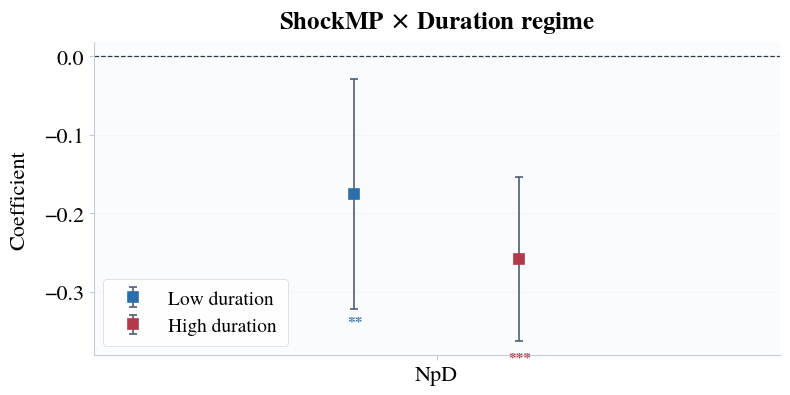

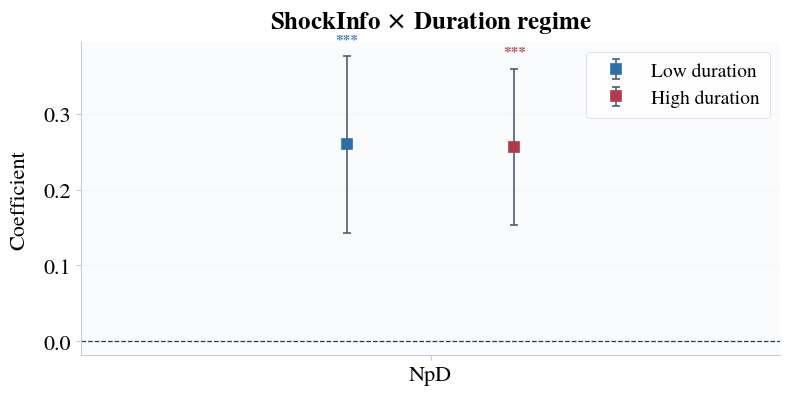

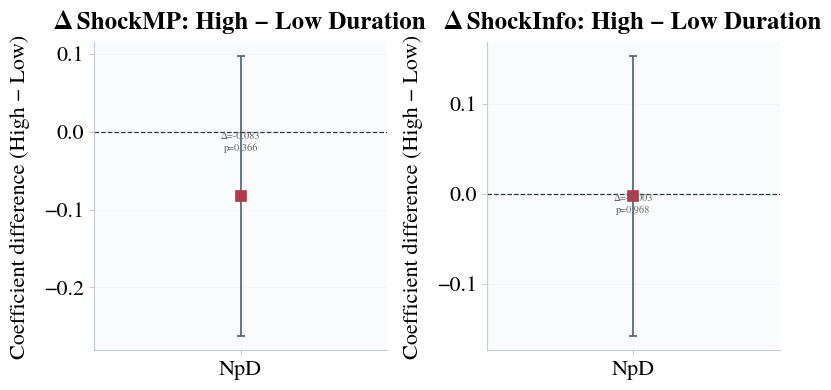

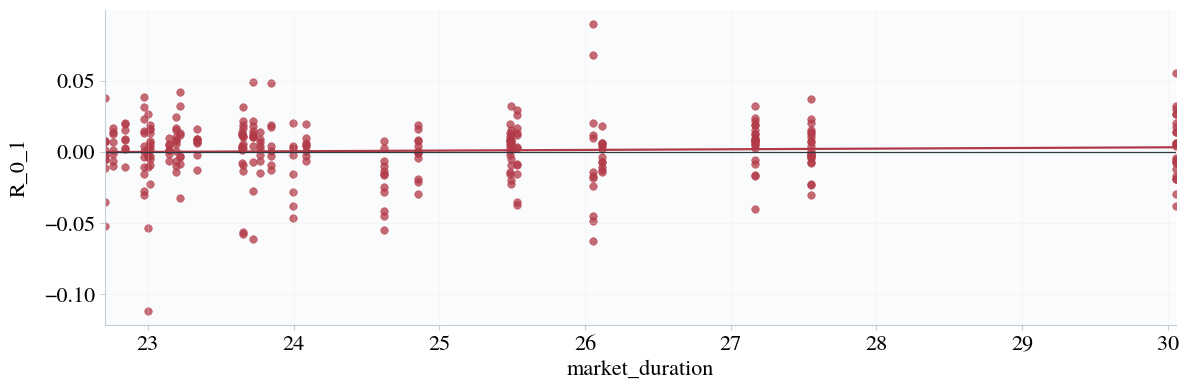

In [16]:
plot_regime_df = regime_results_full.copy()
duration_order = ["NpD"]
regime_order = ["Low", "High"]
x = np.arange(len(duration_order))
# Marker-based layout (consistent with Equities notebook): Low/High as shifted
# markers at the same x-position, rather than bars.
_shift = 0.12
_marker = _DUR_MARKERS.get("NpD", "s")

# --- ShockMP regime markers with CI and significance stars ---
fig, ax = plt.subplots(figsize=(8, 4))
for offset_sign, regime in [(-1, "Low"), (+1, "High")]:
    heights, errs, pvals = [], [], []
    for measure in duration_order:
        row = plot_regime_df.loc[
            (plot_regime_df["duration_measure"] == measure) &
            (plot_regime_df["regime"] == regime)]
        heights.append(float(row["coef(ShockMP)"].iloc[0]))
        errs.append(1.96 * float(row["se(ShockMP)"].iloc[0]))
        pvals.append(float(row["p(ShockMP)"].iloc[0]))
    _color = COLORS["blue"] if regime == "Low" else _DUR_COLORS["NpD"]
    ax.errorbar(x + offset_sign * _shift, heights, yerr=errs,
                fmt=_marker, color=_color, markersize=7,
                markerfacecolor=_color, markeredgecolor=_color,
                markeredgewidth=1.2,
                ecolor=COLORS.get("neutral", "#aaa"),
                capsize=3, capthick=1.2, linewidth=1.2,
                label=f"{regime} duration")
    for ix, (h, p, e) in enumerate(zip(heights, pvals, errs)):
        _star = significance_stars(p)
        if _star and not np.isnan(h):
            _y_off = h + e + abs(h) * 0.05 if h >= 0 else h - e - abs(h) * 0.05
            ax.text(x[ix] + offset_sign * _shift, _y_off, _star, ha="center",
                    va="bottom" if h >= 0 else "top", fontsize=11,
                    color=_color, fontweight="bold")
ax.axhline(0, color=COLORS["reference"], linewidth=0.9, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(duration_order)
ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_ylabel("Coefficient")
ax.set_title("ShockMP $\\times$ Duration regime", fontsize=12, fontweight="bold")
style_axes(ax, grid_axis="y", grid_alpha=0.25)
style_legend(ax, loc="best")
fig.tight_layout()
save_figure(fig, "plot_regime_shockmp_bars", dpi=300)
plt.show()

# --- ShockInfo regime markers with CI and significance stars ---
fig, ax = plt.subplots(figsize=(8, 4))
for offset_sign, regime in [(-1, "Low"), (+1, "High")]:
    heights, errs, pvals = [], [], []
    for measure in duration_order:
        row = plot_regime_df.loc[
            (plot_regime_df["duration_measure"] == measure) &
            (plot_regime_df["regime"] == regime)]
        heights.append(float(row["coef(ShockInfo)"].iloc[0]))
        errs.append(1.96 * float(row["se(ShockInfo)"].iloc[0]))
        pvals.append(float(row["p(ShockInfo)"].iloc[0]))
    _color = COLORS["blue"] if regime == "Low" else _DUR_COLORS["NpD"]
    ax.errorbar(x + offset_sign * _shift, heights, yerr=errs,
                fmt=_marker, color=_color, markersize=7,
                markerfacecolor=_color, markeredgecolor=_color,
                markeredgewidth=1.2,
                ecolor=COLORS.get("neutral", "#aaa"),
                capsize=3, capthick=1.2, linewidth=1.2,
                label=f"{regime} duration")
    for ix, (h, p, e) in enumerate(zip(heights, pvals, errs)):
        _star = significance_stars(p)
        if _star and not np.isnan(h):
            _y_off = h + e + abs(h) * 0.05 if h >= 0 else h - e - abs(h) * 0.05
            ax.text(x[ix] + offset_sign * _shift, _y_off, _star, ha="center",
                    va="bottom" if h >= 0 else "top", fontsize=11,
                    color=_color, fontweight="bold")
ax.axhline(0, color=COLORS["reference"], linewidth=0.9, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(duration_order)
ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_ylabel("Coefficient")
ax.set_title("ShockInfo $\\times$ Duration regime", fontsize=12, fontweight="bold")
style_axes(ax, grid_axis="y", grid_alpha=0.25)
style_legend(ax, loc="best")
fig.tight_layout()
save_figure(fig, "plot_regime_shockinfo_bars", dpi=300)
plt.show()

# --- Delta plot: High minus Low with CI and significance stars ---------------
from scipy import stats as scipy_stats

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

for ax, shock_label, coef_col, se_col in [
    (axes[0], "ShockMP",  "coef(ShockMP)",  "se(ShockMP)"),
    (axes[1], "ShockInfo", "coef(ShockInfo)", "se(ShockInfo)"),
]:
    deltas, delta_ses, delta_ps = [], [], []
    for measure in duration_order:
        row_h = plot_regime_df.loc[
            (plot_regime_df["duration_measure"] == measure) &
            (plot_regime_df["regime"] == "High")]
        row_l = plot_regime_df.loc[
            (plot_regime_df["duration_measure"] == measure) &
            (plot_regime_df["regime"] == "Low")]
        c_h  = float(row_h[coef_col].iloc[0])
        c_l  = float(row_l[coef_col].iloc[0])
        se_h = float(row_h[se_col].iloc[0])
        se_l = float(row_l[se_col].iloc[0])
        n_h  = int(row_h["N"].iloc[0])
        n_l  = int(row_l["N"].iloc[0])

        delta = c_h - c_l
        se_delta = np.sqrt(se_h**2 + se_l**2)
        t_delta = delta / se_delta if se_delta > 0 else np.nan
        p_delta = 2 * (1 - scipy_stats.t.cdf(abs(t_delta), df=max(n_h + n_l - 4, 1))) if not np.isnan(t_delta) else np.nan

        deltas.append(delta)
        delta_ses.append(se_delta)
        delta_ps.append(p_delta)

    x_d = np.arange(len(duration_order))
    errs_d = [1.96 * se for se in delta_ses]
    marker_colors = [_DUR_COLORS.get(d, COLORS["blue"]) for d in duration_order]

    # Per-point errorbar so each duration can have its own colour/marker
    for ix, (d, e, col) in enumerate(zip(deltas, errs_d, marker_colors)):
        ax.errorbar([x_d[ix]], [d], yerr=[e],
                    fmt=_marker, color=col, markersize=7,
                    markerfacecolor=col, markeredgecolor=col,
                    markeredgewidth=1.2,
                    ecolor=COLORS.get("neutral", "#aaa"),
                    capsize=3, capthick=1.2, linewidth=1.2)
    ax.axhline(0, color=COLORS["reference"], linewidth=0.9, linestyle="--")

    for ix, (d, p, e) in enumerate(zip(deltas, delta_ps, errs_d)):
        _star = significance_stars(p)
        if _star and not np.isnan(d):
            _y_off = d + e + abs(d) * 0.05 if d >= 0 else d - e - abs(d) * 0.05
            ax.text(ix, _y_off, _star, ha="center",
                    va="bottom" if d >= 0 else "top",
                    fontsize=11, color=marker_colors[ix], fontweight="bold")
        ax.text(ix, 0, f"Δ={d:.3f}\np={p:.3f}" if not np.isnan(p) else f"Δ={d:.3f}",
                ha="center", va="top" if d < 0 else "bottom",
                fontsize=7.5, color="dimgray", linespacing=1.3)

    ax.set_xticks(x_d)
    ax.set_xticklabels(duration_order)
    ax.set_xlim(-0.5, len(x_d) - 0.5)
    ax.set_title(f"Δ {shock_label}: High − Low Duration")
    ax.set_ylabel("Coefficient difference (High − Low)")
    style_axes(ax, grid_axis="y", grid_alpha=0.25)

fig.tight_layout()
save_figure(fig, "plot_regime_delta_with_ci", dpi=300)
plt.show()

# --- Scatter ---
scatter_duration_df = analysis_sample.dropna(subset=["D_netpayout_yearly_event", "R_0_1"]).copy()
x_vals = scatter_duration_df["D_netpayout_yearly_event"].to_numpy()
y_vals = scatter_duration_df["R_0_1"].to_numpy()
slope, intercept = np.polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(x_vals, y_vals, s=30, alpha=0.75, color=_DUR_COLORS["NpD"])
ax.plot(x_line, intercept + slope * x_line, color=COLORS["accent"], linewidth=1.6)
ax.axhline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_xlabel("market_duration")
ax.set_ylabel("R_0_1")
style_axes(ax, grid_axis="both", grid_alpha=0.25)
fig.tight_layout()
save_figure(fig, "plot_market_duration_scatter_r01", dpi=300)
plt.show()


### Interpretation of Market-Level Results

At the index level, linear interactions are naturally weak because aggregate market duration moves only gradually over time. Once firm-level heterogeneity is collapsed into a single market series, there is much less identifying variation than in the cross section, and the interaction term has to work with a relatively small number of event dates.

The regime split is more robust because it asks a simpler question: does the Euro500 react differently when the market is in a high-duration state versus a low-duration state? That comparison is less sensitive to small measurement error in the level of duration and easier to interpret economically than a continuous slope estimate.

Aggregation also reduces cross-sectional variation. At the firm level, duration differs strongly across companies and sectors; at the market level, those differences are averaged into one portfolio exposure. As a result, market-level duration effects are difficult to detect due to limited time variation and aggregation, but regime-based evidence may still reveal economically meaningful differences.

Taken together, the notebook should answer three questions. First, the Euro500 does react to ECB monetary-policy and information shocks. Second, market duration may matter, but the evidence is clearer in discrete high-versus-low duration states than in linear interactions. Third, the effect is most informative when attention is restricted to large shocks, where the signal-to-noise ratio is stronger.


### Robustness 1: Year-over-year Changes in Market Duration


In [17]:
# ── Robustness 1: Year-over-year change in NpD market duration ────────────

# Year-over-year change in the annual NpD series (already 1-year lagged)
market_duration_yearly = market_duration_yearly.sort_values("year").reset_index(drop=True)
market_duration_yearly["delta_npd"] = market_duration_yearly["market_duration_netpayout"].diff()
market_duration_yearly["delta_npd_z"] = standardize_series(market_duration_yearly["delta_npd"])

# Map ΔNpD to events via the same 1-year-lag convention
_delta_lookup = market_duration_yearly[["year", "delta_npd", "delta_npd_z"]].copy()
_delta_lookup["event_year"] = _delta_lookup["year"] + 1  # events in y use ΔNpD from y-1
_fd_sample = event_dataset_yearly.merge(
    _delta_lookup.drop(columns=["year"]),
    on="event_year",
    how="left",
).dropna(subset=[
    "ShockMP", "ShockInfo", "R_0", "R_0_1", "delta_npd_z",
]).copy()
print(f"First-difference sample: {len(_fd_sample):,} events")

_fd_rows = []
for return_window in ["R_0", "R_0_1"]:
    for calendar_controls, model_label in [(False, "Model 1"), (True, "Model 2")]:
        work, X, y = build_design_matrix(
            _fd_sample, y_col=return_window,
            duration_col="delta_npd_z",
            include_both_shocks=True,
            calendar_controls=calendar_controls,
        )
        res = fit_ols(y, X, cov_type="HC1")
        _fd_rows.append({
            "model": model_label,
            "return_window": return_window,
            "duration_col": "ΔNpD (z-scored)",
            "coef(ShockMP×ΔD)": res.params.get("mp_x_d", np.nan),
            "t(ShockMP×ΔD)": res.tvalues.get("mp_x_d", np.nan),
            "p(ShockMP×ΔD)": res.pvalues.get("mp_x_d", np.nan),
            "coef(ShockInfo×ΔD)": res.params.get("info_x_d", np.nan),
            "t(ShockInfo×ΔD)": res.tvalues.get("info_x_d", np.nan),
            "p(ShockInfo×ΔD)": res.pvalues.get("info_x_d", np.nan),
            "N": int(res.nobs),
            "R2": res.rsquared,
        })

rob1_first_diff = pd.DataFrame(_fd_rows)
rob1_first_diff.to_csv(output_dir / "index_robustness_first_differences.csv", index=False)

print("Robustness 1: Year-over-year first differences of market duration")
display(rob1_first_diff)


First-difference sample: 287 events
Robustness 1: Year-over-year first differences of market duration


,model,return_window,duration_col,coef(ShockMP×ΔD),t(ShockMP×ΔD),p(ShockMP×ΔD),coef(ShockInfo×ΔD),t(ShockInfo×ΔD),p(ShockInfo×ΔD),N,R2
0,Model 1,R_0,ΔNpD (z-scored),0.032260,1.672876,0.094352,-0.041333,-1.844046,0.065176,287,0.346075
1,Model 2,R_0,ΔNpD (z-scored),0.032680,1.858032,0.063164,-0.037366,-1.632561,0.102561,287,0.406119
2,Model 1,R_0_1,ΔNpD (z-scored),0.003499,0.135238,0.892424,-0.007919,-0.270422,0.786835,287,0.228238
3,Model 2,R_0_1,ΔNpD (z-scored),0.001960,0.079080,0.936969,-0.004149,-0.138662,0.889717,287,0.289782


### Robustness 2: Rolling 5-Year Window Regime Regression

To assess the temporal stability of the duration regime effect, the
High-minus-Low coefficient difference is re-estimated on rolling
5-year windows. Each window contains the ECB events that fall within
the 60 months preceding its end date; the regime split is computed
within the window using the median of the event-matched
`D_netpayout_yearly_event` observations.

**Interpretive caveat.** Because the duration regressor is annual, a
5-year window contains at most five distinct duration values. A within-
window median split therefore partitions the aggregate duration history
into at most two or three "high" years and two or three "low" years.
This reduces the effective cross-sectional variation compared with what
would be available under a denser (e.g. quarterly) regressor, and makes
each window's $\Delta_{\text{MP}}$ estimate inherently noisier. The
notebook skips windows with fewer than 20 events or fewer than two
distinct duration values; the remaining windows are informative about
the *direction and broad time profile* of the regime effect, but point
estimates in individual windows should not be read as precise
measurements. Structural break markers around the GFC (2008) and the
onset of large-scale asset purchases (2015) are drawn on the plot
as visual anchors.


Rolling regime results: 52 windows


,duration_measure,sample,Delta_MP,Delta_Info,median_duration,N_total,window_end,n_events
0,NpD,Rolling 2000-12-14,0.160583,0.103049,30.058233,45,2000-12-14,45
1,NpD,Rolling 2001-06-07,0.158964,0.067855,27.550159,57,2001-06-07,57
2,NpD,Rolling 2001-06-21,0.159796,0.069237,27.550159,58,2001-06-21,58
3,NpD,Rolling 2001-12-06,0.201506,0.017063,27.550159,67,2001-12-06,67
4,NpD,Rolling 2002-06-06,0.310904,0.006821,27.550159,73,2002-06-06,73
5,NpD,Rolling 2002-12-05,0.294137,-0.174254,27.550159,79,2002-12-05,79
6,NpD,Rolling 2003-06-05,0.229152,-0.068195,27.550159,85,2003-06-05,85
7,NpD,Rolling 2003-12-04,0.127041,-0.158364,27.166243,91,2003-12-04,91
8,NpD,Rolling 2004-06-03,0.097734,-0.100053,27.550159,88,2004-06-03,88
9,NpD,Rolling 2004-12-02,0.013660,-0.225956,27.550159,83,2004-12-02,83


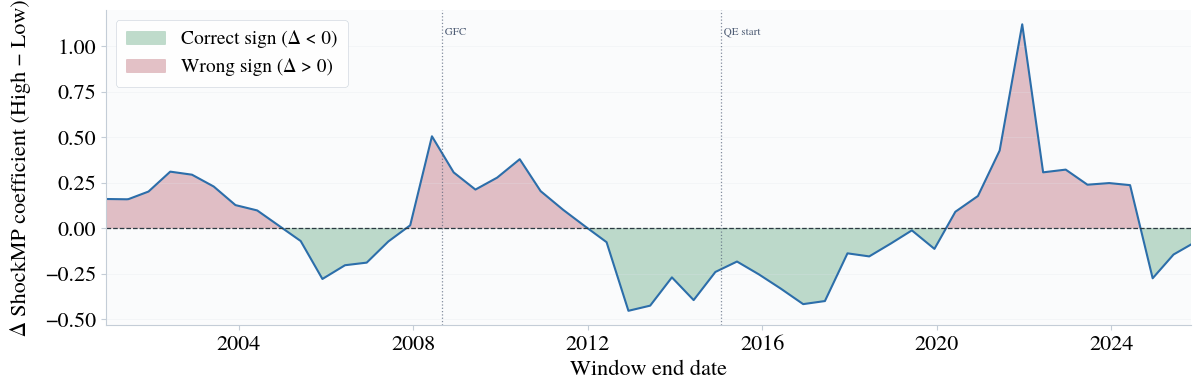

In [18]:
# ── Robustness 2: Rolling 5-year window regime regression ─────────────────

window_months = 60
step_months = 6

rolling_rows = []
dates = sorted(analysis_sample["event_date"].unique())

for end_date in dates:
    start_date = end_date - pd.DateOffset(months=window_months)
    window_df = analysis_sample[
        (analysis_sample["event_date"] >= start_date) &
        (analysis_sample["event_date"] <= end_date)
    ].copy()

    if window_df["D_netpayout_yearly_event"].notna().sum() < 20:
        continue
    # Skip windows where yearly NpD is (near-)constant — a single distinct
    # value leaves one regime group empty after a median split.
    if window_df["D_netpayout_yearly_event"].nunique() < 2:
        continue

    _, delta_row = run_duration_regime_table(
        window_df,
        duration_col="D_netpayout_yearly_event",
        duration_label="NpD",
        sample_label=f"Rolling {str(end_date)[:10]}",
    )
    delta_row["window_end"] = end_date
    delta_row["n_events"] = len(window_df)
    rolling_rows.append(delta_row)

rolling_results = pd.concat(rolling_rows, ignore_index=True)

# Keep only semi-annual window ends to reduce overlap
rolling_results = rolling_results[
    rolling_results["window_end"].dt.month.isin([6, 12])
    | (rolling_results["window_end"] == rolling_results["window_end"].max())
].copy().reset_index(drop=True)
rolling_results = rolling_results.dropna(subset=["Delta_MP"]).reset_index(drop=True)

rolling_results.to_csv(output_dir / "index_robustness_rolling_regime.csv", index=False)

print(f"Rolling regime results: {len(rolling_results)} windows")
display(rolling_results)

# ── Plot ──
fig, ax = plt.subplots(figsize=(12, 4))
x_dates = rolling_results["window_end"]
y_delta = rolling_results["Delta_MP"].astype(float)

ax.fill_between(
    x_dates, 0, y_delta,
    where=(y_delta <= 0), interpolate=True,
    color=COLORS["green"], alpha=0.3, label="Correct sign (Δ < 0)",
)
ax.fill_between(
    x_dates, 0, y_delta,
    where=(y_delta > 0), interpolate=True,
    color=COLORS["red"], alpha=0.3, label="Wrong sign (Δ > 0)",
)
ax.plot(x_dates, y_delta, color=COLORS["blue"], linewidth=1.5)
ax.axhline(0, color=COLORS["reference"], linewidth=0.9, linestyle="--")

# Structural break markers
for event_date, label in [(pd.Timestamp("2008-09-01"), "GFC"),
                           (pd.Timestamp("2015-01-22"), "QE start")]:
    if x_dates.min() <= event_date <= x_dates.max():
        ax.axvline(event_date, color=COLORS["neutral"],
                   linewidth=0.9, linestyle=":", alpha=0.7)
        ax.text(event_date, ax.get_ylim()[1] * 0.92, f" {label}",
                fontsize=8, va="top", color=COLORS["neutral"])

ax.set_xlabel("Window end date")
ax.set_ylabel("Δ ShockMP coefficient (High − Low)")
style_axes(ax, grid_axis="y", grid_alpha=0.25)
style_legend(ax, loc="best")
fig.tight_layout()
save_figure(fig, "plot_rolling_regime_delta", dpi=300)
plt.show()

### Robustness 3: Alternative Regime Thresholds (P33/P67 and P25/P75)

The median split into High- and Low-duration regimes is arbitrary. We verify that the direction and approximate magnitude of the regime difference is stable across alternative threshold choices (P33/P67, P25/P75).


Robustness 3: Alternative regime thresholds


,threshold,duration_measure,regime,coef_ShockMP,se_ShockMP,t_ShockMP,p_ShockMP,N
0,P50/P50,NpD,High,-0.258513,0.053252,-4.854530,0.000001,159
1,P50/P50,NpD,Low,-0.175362,0.074762,-2.345611,0.018996,150
2,P50/P50,NpD,Delta (High - Low),-0.083150,0.091788,-0.905889,0.365710,309
3,P33/P67,NpD,High,-0.248911,0.057439,-4.333442,0.000015,103
4,P33/P67,NpD,Low,-0.152130,0.091851,-1.656259,0.097669,102
5,P33/P67,NpD,Delta (High - Low),-0.096781,0.108333,-0.893367,0.372729,205
6,P25/P75,NpD,High,-0.202196,0.059883,-3.376521,0.000734,79
7,P25/P75,NpD,Low,-0.161584,0.120505,-1.340891,0.179956,78
8,P25/P75,NpD,Delta (High - Low),-0.040613,0.134564,-0.301812,0.763205,157


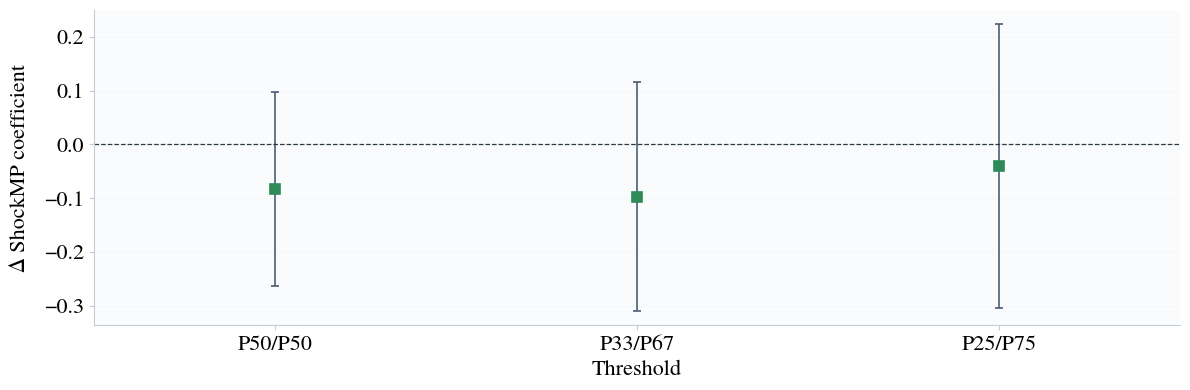

In [19]:
# ── Robustness 3: Alternative regime thresholds ──────────────────────────

def run_regime_threshold(df, duration_col, duration_label,
                         lo_q, hi_q, y_col="R_0_1"):
    subset = df.dropna(
        subset=[duration_col, y_col, "ShockMP", "ShockInfo"]).copy()
    lo_val = subset[duration_col].quantile(lo_q)
    hi_val = subset[duration_col].quantile(hi_q)
    # Only keep observations in bottom lo_q or top (1-hi_q) — drop middle
    mask = (subset[duration_col] <= lo_val) | (subset[duration_col] >= hi_val)
    subset = subset[mask].copy()
    subset["regime"] = np.where(
        subset[duration_col] >= hi_val, "High", "Low")

    rows = []
    beta_store = {}
    se_store = {}
    for regime in ["High", "Low"]:
        part = subset[subset["regime"] == regime].copy()
        res, _ = fit_baseline_market_regression(
            part, y_col=y_col, cov_type="HC1")
        beta_store[regime] = res.params
        se_store[regime] = res.bse
        rows.append({
            "threshold": f"P{int(lo_q*100)}/P{int(hi_q*100)}",
            "duration_measure": duration_label,
            "regime": regime,
            "coef_ShockMP": res.params.get("ShockMP", np.nan),
            "se_ShockMP": res.bse.get("ShockMP", np.nan),
            "t_ShockMP": res.tvalues.get("ShockMP", np.nan),
            "p_ShockMP": res.pvalues.get("ShockMP", np.nan),
            "N": int(res.nobs),
        })
    delta = (beta_store.get("High", {}).get("ShockMP", np.nan) -
             beta_store.get("Low",  {}).get("ShockMP", np.nan))
    # SE for delta via sqrt(se_high^2 + se_low^2) (independent samples)
    se_high = se_store.get("High", {}).get("ShockMP", np.nan)
    se_low = se_store.get("Low", {}).get("ShockMP", np.nan)
    se_delta = np.sqrt(se_high**2 + se_low**2) if not (np.isnan(se_high) or np.isnan(se_low)) else np.nan
    t_delta = delta / se_delta if se_delta and not np.isnan(se_delta) and se_delta > 0 else np.nan
    from scipy import stats as scipy_stats
    n_total = len(subset)
    p_delta = 2 * (1 - scipy_stats.t.cdf(abs(t_delta), df=max(n_total - 4, 1))) if not np.isnan(t_delta) else np.nan
    rows.append({
        "threshold": f"P{int(lo_q*100)}/P{int(hi_q*100)}",
        "duration_measure": duration_label,
        "regime": "Delta (High - Low)",
        "coef_ShockMP": delta,
        "se_ShockMP": se_delta,
        "t_ShockMP": t_delta,
        "p_ShockMP": p_delta,
        "N": n_total,
    })
    return pd.DataFrame(rows)


threshold_results = pd.concat([
    run_regime_threshold(analysis_sample, "D_netpayout_yearly_event",
                         "NpD", 0.50, 0.50, y_col="R_0_1"),
    run_regime_threshold(analysis_sample, "D_netpayout_yearly_event",
                         "NpD", 0.33, 0.67, y_col="R_0_1"),
    run_regime_threshold(analysis_sample, "D_netpayout_yearly_event",
                         "NpD", 0.25, 0.75, y_col="R_0_1"),
], ignore_index=True)

threshold_results.to_csv(output_dir / "index_robustness_thresholds.csv", index=False)

print("Robustness 3: Alternative regime thresholds")
display(threshold_results)

# ── Plot ──
delta_rows = threshold_results[threshold_results["regime"] == "Delta (High - Low)"].copy()
x_labels = delta_rows["threshold"].tolist()
y_vals = delta_rows["coef_ShockMP"].astype(float).tolist()
y_errs = [1.96 * float(se) if not np.isnan(se) else 0.0 for se in delta_rows["se_ShockMP"]]
p_vals = delta_rows["p_ShockMP"].astype(float).tolist()
marker_colors = [COLORS.get("green", "#2ca02c") if v <= 0 else COLORS.get("red", "#d62728") for v in y_vals]
_marker = _DUR_MARKERS.get("NpD", "s")

fig, ax = plt.subplots(figsize=(12, 4))
x_positions = np.arange(len(x_labels))
for ix, (v, e, col) in enumerate(zip(y_vals, y_errs, marker_colors)):
    ax.errorbar([x_positions[ix]], [v], yerr=[e],
                fmt=_marker, color=col, markersize=7,
                markerfacecolor=col, markeredgecolor=col,
                markeredgewidth=1.2,
                ecolor=COLORS.get("neutral", "#aaa"),
                capsize=3, capthick=1.2, linewidth=1.2)

for ix, (v, p, e) in enumerate(zip(y_vals, p_vals, y_errs)):
    _star = significance_stars(p)
    if _star and not np.isnan(v):
        _y_off = v + e + abs(v) * 0.05 if v >= 0 else v - e - abs(v) * 0.05
        ax.text(ix, _y_off, _star, ha="center",
                va="bottom" if v >= 0 else "top", fontsize=11,
                color=marker_colors[ix], fontweight="bold")
ax.axhline(0, color=COLORS["reference"], linewidth=0.9, linestyle="--")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)
ax.set_xlim(-0.5, len(x_positions) - 0.5)
ax.set_xlabel("Threshold")
ax.set_ylabel("Δ ShockMP coefficient")
style_axes(ax, grid_axis="y", grid_alpha=0.22)
fig.tight_layout()
save_figure(fig, "plot_threshold_robustness", dpi=300)
plt.show()


### Robustness 4: Further-lagged Market Duration (NpD from t-2)


In [20]:
# ── Robustness 4: Further lagged market duration (NpD from year t-2) ──────

# Baseline design uses NpD from year t-1; here we additionally lag to year t-2
# to test whether any misspecified timing drives the headline result.
_lag_lookup = market_duration_yearly[["year", "market_duration_netpayout",
                                        "market_duration_netpayout_z"]].copy()
_lag_lookup = _lag_lookup.rename(columns={
    "market_duration_netpayout":   "npd_t2",
    "market_duration_netpayout_z": "npd_t2_z",
})
_lag_lookup["event_year"] = _lag_lookup["year"] + 2  # events in y use NpD from y-2
_lag_sample = event_dataset_yearly.merge(
    _lag_lookup.drop(columns=["year"]),
    on="event_year",
    how="left",
).dropna(subset=[
    "ShockMP", "ShockInfo", "R_0", "R_0_1", "npd_t2_z",
]).copy()
print(f"Further-lagged sample (NpD t-2): {len(_lag_sample):,} events")

_lag_rows = []
for return_window in ["R_0", "R_0_1"]:
    for calendar_controls, model_label in [(False, "Model 1"), (True, "Model 2")]:
        # Further lag (t-2)
        work, X, y = build_design_matrix(
            _lag_sample, y_col=return_window,
            duration_col="npd_t2_z",
            include_both_shocks=True,
            calendar_controls=calendar_controls,
        )
        res_lag = fit_ols(y, X, cov_type="HC1")

        # Levels (baseline t-1) for comparison — from analysis_sample
        _lev_sub = analysis_sample.dropna(
            subset=[return_window, "D_netpayout_yearly_event", "ShockMP", "ShockInfo"]).copy()
        _lev_sub["D_npd_z"] = standardize_series(_lev_sub["D_netpayout_yearly_event"])
        work_l, X_l, y_l = build_design_matrix(
            _lev_sub, y_col=return_window,
            duration_col="D_npd_z",
            include_both_shocks=True,
            calendar_controls=calendar_controls,
        )
        res_lev = fit_ols(y_l, X_l, cov_type="HC1")

        _lag_rows.append({
            "model": model_label,
            "return_window": return_window,
            "variant": "Baseline (NpD t-1)",
            "coef(ShockMP×D)": res_lev.params.get("mp_x_d", np.nan),
            "t(ShockMP×D)": res_lev.tvalues.get("mp_x_d", np.nan),
            "p(ShockMP×D)": res_lev.pvalues.get("mp_x_d", np.nan),
            "N": int(res_lev.nobs),
        })
        _lag_rows.append({
            "model": model_label,
            "return_window": return_window,
            "variant": "Further lag (NpD t-2)",
            "coef(ShockMP×D)": res_lag.params.get("mp_x_d", np.nan),
            "t(ShockMP×D)": res_lag.tvalues.get("mp_x_d", np.nan),
            "p(ShockMP×D)": res_lag.pvalues.get("mp_x_d", np.nan),
            "N": int(res_lag.nobs),
        })

rob4_lagged = pd.DataFrame(_lag_rows)
rob4_lagged.to_csv(output_dir / "index_robustness_lagged_duration.csv", index=False)

print("Robustness 4: Baseline (t-1) vs further-lagged (t-2) market duration")
display(rob4_lagged)


Further-lagged sample (NpD t-2): 287 events
Robustness 4: Baseline (t-1) vs further-lagged (t-2) market duration


,model,return_window,variant,coef(ShockMP×D),t(ShockMP×D),p(ShockMP×D),N
0,Model 1,R_0,Baseline (NpD t-1),0.005426,0.140045,0.888624,309
1,Model 1,R_0,Further lag (NpD t-2),-0.011350,-0.351035,0.725562,287
2,Model 2,R_0,Baseline (NpD t-1),-0.000467,-0.013597,0.989151,309
3,Model 2,R_0,Further lag (NpD t-2),-0.017283,-0.643718,0.519758,287
4,Model 1,R_0_1,Baseline (NpD t-1),-0.031112,-0.750001,0.453254,309
5,Model 1,R_0_1,Further lag (NpD t-2),-0.030511,-0.849060,0.395848,287
6,Model 2,R_0_1,Baseline (NpD t-1),-0.037326,-0.957531,0.338299,309
7,Model 2,R_0_1,Further lag (NpD t-2),-0.036568,-1.166889,0.243255,287


### Robustness Summary

The table below consolidates the key result from each robustness check into a single compact view.


In [21]:
# ── Robustness summary across all four checks ────────────────────────────

_summary_rows = []

# Rob 1: First differences — Model 1, R_0_1
_r1 = rob1_first_diff[(rob1_first_diff["model"] == "Model 1") & (rob1_first_diff["return_window"] == "R_0_1")]
if len(_r1):
    _r1 = _r1.iloc[0]
    _summary_rows.append({
        "Check": r"Year-over-year $\Delta$NpD",
        "Duration": "ΔNpD (z)",
        "Return": "R_0_1",
        "N": _r1["N"],
        "coef(ShockMP×D)": _r1["coef(ShockMP×ΔD)"],
        "t-stat": _r1["t(ShockMP×ΔD)"],
        "p-value": np.nan,
        "Sign correct?": _r1["coef(ShockMP×ΔD)"] < 0,
    })

# Rob 2: Rolling regime — summarise Delta_MP across all windows.
# No per-window t is stored in rolling_results; instead we compute a
# one-sample t-statistic on the Delta_MP series itself (H0: mean Delta_MP
# = 0 across windows). This is descriptive because the 60-month rolling
# windows overlap (halfyear step), so the implied variance understates
# serial dependence — we therefore do not attach a p-value and do not
# show significance stars on this row.
if len(rolling_results):
    _r2_series = rolling_results["Delta_MP"].astype(float).dropna()
    _r2_median = _r2_series.median()
    _r2_n = len(_r2_series)
    _r2_mean = _r2_series.mean()
    _r2_sd = _r2_series.std(ddof=1)
    _r2_t = _r2_mean / (_r2_sd / np.sqrt(_r2_n)) if (_r2_sd > 0 and _r2_n > 1) else np.nan
    _summary_rows.append({
        "Check": r"Rolling 5yr regime (median $\Delta$)",
        "Duration": "NpD regime",
        "Return": "R_0_1",
        "N": int(rolling_results["n_events"].median()),
        "coef(ShockMP×D)": _r2_median,
        "t-stat": _r2_t,
        "p-value": np.nan,  # overlapping windows — t is descriptive only
        "Sign correct?": _r2_median < 0,
    })

# Rob 3: Threshold — P50 delta
_r3 = threshold_results[
    (threshold_results["threshold"] == "P50/P50") &
    (threshold_results["regime"] == "Delta (High - Low)")
]
if len(_r3):
    _r3 = _r3.iloc[0]
    _summary_rows.append({
        "Check": "Regime P50 (median)",
        "Duration": "NpD regime",
        "Return": "R_0_1",
        "N": _r3["N"],
        "coef(ShockMP×D)": _r3["coef_ShockMP"],
        "t-stat": _r3["t_ShockMP"],
        "p-value": _r3["p_ShockMP"],
        "Sign correct?": _r3["coef_ShockMP"] < 0,
    })
_r3b = threshold_results[
    (threshold_results["threshold"] == "P33/P67") &
    (threshold_results["regime"] == "Delta (High - Low)")
]
if len(_r3b):
    _r3b = _r3b.iloc[0]
    _summary_rows.append({
        "Check": "Regime P33/P67",
        "Duration": "NpD regime",
        "Return": "R_0_1",
        "N": _r3b["N"],
        "coef(ShockMP×D)": _r3b["coef_ShockMP"],
        "t-stat": _r3b["t_ShockMP"],
        "p-value": _r3b["p_ShockMP"],
        "Sign correct?": _r3b["coef_ShockMP"] < 0,
    })
_r3c = threshold_results[
    (threshold_results["threshold"] == "P25/P75") &
    (threshold_results["regime"] == "Delta (High - Low)")
]
if len(_r3c):
    _r3c = _r3c.iloc[0]
    _summary_rows.append({
        "Check": "Regime P25/P75",
        "Duration": "NpD regime",
        "Return": "R_0_1",
        "N": _r3c["N"],
        "coef(ShockMP×D)": _r3c["coef_ShockMP"],
        "t-stat": _r3c["t_ShockMP"],
        "p-value": _r3c["p_ShockMP"],
        "Sign correct?": _r3c["coef_ShockMP"] < 0,
    })

# Rob 4: Lagged duration — Model 1, R_0_1
_r4 = rob4_lagged[
    (rob4_lagged["model"] == "Model 1") &
    (rob4_lagged["return_window"] == "R_0_1") &
    (rob4_lagged["variant"] == "Further lag (NpD t-2)")
]
if len(_r4):
    _r4 = _r4.iloc[0]
    _summary_rows.append({
        "Check": "Further-lagged NpD (t-2)",
        "Duration": "NpD t-2 (z)",
        "Return": "R_0_1",
        "N": _r4["N"],
        "coef(ShockMP×D)": _r4["coef(ShockMP×D)"],
        "t-stat": _r4["t(ShockMP×D)"],
        "p-value": np.nan,
        "Sign correct?": _r4["coef(ShockMP×D)"] < 0,
    })

rob_summary = pd.DataFrame(_summary_rows)
rob_summary.to_csv(output_dir / "index_robustness_summary.csv", index=False)

print("Robustness summary across all four checks:")
display(rob_summary)

# ── LaTeX robustness summary table ───────────────────────────────────────────

def _fmt_coef_with_phantom(coef, p=np.nan):
    if pd.isna(coef):
        return ""
    stars = _tex_stars(p) if not pd.isna(p) else ""
    if coef >= 0:
        return r"$\phantom{-}" + f"{coef:.4f}" + r"$" + stars
    else:
        return f"${coef:.4f}$" + stars


_L = []
_L.append(r"\begin{table}[htbp]")
_L.append(r"\centering\small")
_L.append(r"\caption{\textsc{Index-Level Robustness Summary}}")
_L.append(r"\label{tab:index_robustness_summary}")
_L.append(r"\begin{tabular}{lccr}")
_L.append(r"\toprule")
_L.append(r"Check & Coef.\ (ShockMP$\times$D) & $t$-stat & $N$ \\")
_L.append(r"\midrule")

for _, row in rob_summary.iterrows():
    _coef_str = _fmt_coef_with_phantom(
        row["coef(ShockMP×D)"], p=row.get("p-value", np.nan)
    )
    _t_str = f"${row['t-stat']:.2f}$" if pd.notna(row["t-stat"]) else "--"
    _n = f"{int(row['N']):,}" if pd.notna(row["N"]) else ""
    _L.append(f"{row['Check']} & {_coef_str} & {_t_str} & {_n} \\\\")

_L.append(r"\bottomrule")
_L.append(r"\end{tabular}")
_L.append("")
_L.append(r"\vspace{4pt}")
_L.append(r"\begin{minipage}{\textwidth}")
_L.append(r"\footnotesize")
_L.append(
    r"\textit{Notes.} Each row reports the ShockMP$\times$Duration interaction "
    r"coefficient (or, for regime splits, the High$-$Low difference) under the "
    r"alternative specification described in the first column. "
    r"$t$-statistics for the year-over-year and t-2 "
    r"checks are model-based; for the regime checks they are Welch-type "
    r"pooled differences treating the two regime samples as independent. "
    r"For the rolling 5yr row the $t$-statistic is a one-sample test of "
    r"whether the mean High$-$Low coefficient differs from zero across "
    r"the 59 overlapping 60-month windows; because the windows overlap, "
    r"the implied standard error understates serial dependence and the "
    r"value is descriptive only, with no associated $p$-value. "
    r"Significance stars are reported only where a single $p$-value is "
    r"available. $^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$."
)
_L.append(r"\end{minipage}")
_L.append(r"\end{table}")

_tex_robsum = "\n".join(_L)
_out_robsum = output_dir / "tab_index_robustness_summary.tex"
_out_robsum.write_text(_tex_robsum, encoding="utf-8")
print(f"\nSaved: {_out_robsum}")
print()
print("--- Preview: tab_index_robustness_summary.tex (first 1500 chars) ---")
print(_tex_robsum[:1500])


Robustness summary across all four checks:


,Check,Duration,Return,N,coef(ShockMP×D),t-stat,p-value,Sign correct?
0,Year-over-year $\Delta$NpD,ΔNpD (z),R_0_1,287,0.003499,0.135238,NaN,False
1,Rolling 5yr regime (median $\Delta$),NpD regime,R_0_1,59,0.014812,0.784428,NaN,False
2,Regime P50 (median),NpD regime,R_0_1,309,-0.083150,-0.905889,0.365710,True
3,Regime P33/P67,NpD regime,R_0_1,205,-0.096781,-0.893367,0.372729,True
4,Regime P25/P75,NpD regime,R_0_1,157,-0.040613,-0.301812,0.763205,True
5,Further-lagged NpD (t-2),NpD t-2 (z),R_0_1,287,-0.030511,-0.849060,NaN,True



Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/ECBShocks_Index_Regressions/tab_index_robustness_summary.tex

--- Preview: tab_index_robustness_summary.tex (first 1500 chars) ---
\begin{table}[htbp]
\centering\small
\caption{\textsc{Index-Level Robustness Summary}}
\label{tab:index_robustness_summary}
\begin{tabular}{lccr}
\toprule
Check & Coef.\ (ShockMP$\times$D) & $t$-stat & $N$ \\
\midrule
Year-over-year $\Delta$NpD & $\phantom{-}0.0035$ & $0.14$ & 287 \\
Rolling 5yr regime (median $\Delta$) & $\phantom{-}0.0148$ & $0.78$ & 59 \\
Regime P50 (median) & $-0.0832$ & $-0.91$ & 309 \\
Regime P33/P67 & $-0.0968$ & $-0.89$ & 205 \\
Regime P25/P75 & $-0.0406$ & $-0.30$ & 157 \\
Further-lagged NpD (t-2) & $-0.0305$ & $-0.85$ & 287 \\
\bottomrule
\end{tabular}

\vspace{4pt}
\begin{minipage}{\textwidth}
\footnotesize
\textit{Notes.} Each row reports the ShockMP$\times$Duration interaction coefficient (or, for regime splits, the High$-$Low

### Robustness 5: Aggregate FcstD Market Duration

As a further robustness check, we re-estimate the baseline index-level
regression using the value-weighted average of Forecast Duration (FcstD)
across non-financial Euro\,500 constituents. FcstD is available from 2003
onward (coverage of I/B/E/S consensus forecasts for euro-area firms is
limited before then). Because approximately 71\% of the FcstD present
value sits in the post-year-30 terminal component (see Section 4.2.1 and
Appendix~B.6 of the thesis), aggregate FcstD captures a mixture of growth
valuation and earnings timing rather than pure cash-flow duration; we
therefore expect and obtain weaker interaction coefficients than for NpD.
This check is reported here for completeness and is discussed briefly in
the thesis as a robustness note.


In [22]:
# ── Robustness 5: FcstD aggregate market duration ────────────────────────────

fcstd_sample = main_sample.dropna(subset=["market_duration_fcstd_z"]).copy()
print(f"FcstD robustness sample: {len(fcstd_sample):,} events "
      f"(coverage restricted to post-2003)")

_specs_fcstd = [("market_duration_fcstd_z", "FcstD", "value_weighted")]
_fcstd_rows = []
for duration_col, duration_variant, duration_weighting in _specs_fcstd:
    for return_window in ["R_0", "R_0_1"]:
        subset = fcstd_sample.dropna(
            subset=[duration_col, return_window,
                    "ShockMP", "ShockInfo"]).copy()
        _fcstd_rows.extend(run_model_suite(
            subset, duration_col, duration_variant,
            duration_weighting, return_window, cov_type="HC1",
        ))
results_fcstd = pd.DataFrame(_fcstd_rows)

_title_fcstd = r"Aggregate FcstD Market Duration (Robustness)"
_notes_fcstd = (
    r"Robustness check re-estimating the baseline index-level regression "
    r"using the value-weighted Forecast Duration (FcstD) instead of NpD. "
    r"FcstD is available from 2003, restricting the sample relative to "
    r"Table~\ref{tab:index_main_npd}. Because approximately 71\% of the "
    r"FcstD present value sits in the post-year-30 terminal component, "
    r"aggregate FcstD captures a mixture of growth valuation and earnings "
    r"timing rather than pure cash-flow duration; the interaction "
    r"coefficients are therefore expected to be weaker than for NpD. "
    r"Heteroskedasticity-robust (HC1) standard errors in parentheses. "
    r"$^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$."
)
_tex_fcstd = _build_latex_stargazer_index(
    results_fcstd[results_fcstd["duration_weighting"] == "value_weighted"],
    panels=[
        (r"Event-day return~$R_{0}$",
         {"duration_variant": "FcstD", "return_window": "R_0"},
         "FcstD"),
        (r"Two-day cumulative return~$R_{0,1}$",
         {"duration_variant": "FcstD", "return_window": "R_0_1"},
         "FcstD"),
    ],
    title=_title_fcstd,
    notes=_notes_fcstd,
    label="index_fcstd_robustness",
    outpath=output_dir / "tab_index_fcstd_robustness.tex",
)

print()
print("--- Preview: tab_index_fcstd_robustness.tex (first 1500 chars) ---")
print(_tex_fcstd[:1500])


FcstD robustness sample: 309 events (coverage restricted to post-2003)


Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/ECBShocks_Index_Regressions/tab_index_fcstd_robustness.tex

--- Preview: tab_index_fcstd_robustness.tex (first 1500 chars) ---
\begin{table}[htbp]
\centering\small
\caption{\textsc{Aggregate FcstD Market Duration (Robustness)}}
\label{tab:index_fcstd_robustness}
\begin{tabular}{lcc}
\toprule
 & (1) & (2) \\
 & M1 & M2 \\
\midrule
\multicolumn{3}{l}{\textit{Panel A: Event-day return~$R_{0}$}} \\
ShockMP & $-0.1888$$^{***}$~$(0.0548)$ & $-0.1792$$^{***}$~$(0.0485)$ \\
ShockMP $\times$ FcstD & $-0.0265$~$(0.0282)$ & $-0.0252$~$(0.0292)$ \\
ShockInfo & $\phantom{-}0.2283$$^{***}$~$(0.0348)$ & $\phantom{-}0.2280$$^{***}$~$(0.0373)$ \\
ShockInfo $\times$ FcstD & $-0.0108$~$(0.0182)$ & $-0.0173$~$(0.0208)$ \\
Observations & 309 & 309 \\
$R^{2}$ & $0.337$ & $0.398$ \\
\midrule
\multicolumn{3}{l}{\textit{Panel B: Two-day cumulative return~$R_{0,1}$}} \\
ShockMP & $-0.1940$$^{***}$~$(0.0524)$ & 

### Extension A: Subperiod Analysis

We split the full sample at three structural break dates to test whether the
aggregate market's ECB-shock sensitivity, and its dependence on market duration,
is stable over time or concentrated in a particular regime.

The three cuts are:
- **Pre/Post GFC**: September 2008 (Lehman collapse)
- **Pre/Post Zero Lower Bound**: January 2014 (ECB deposit rate first hits zero / QE era begins)
- **Pre/Post COVID**: March 2020

For each subperiod we estimate the baseline shock regression (no duration
interaction) and the NpD regime split. This tells us (i) whether the index-level
shock response itself is stable and (ii) whether the High-minus-Low duration
difference concentrates in a specific macro regime.

EXTENSION A: SUBPERIOD ANALYSIS
Baseline shock sensitivity by subperiod (R_0_1):


,split,period,N,coef(ShockMP),se(ShockMP),t(ShockMP),p(ShockMP),coef(ShockInfo),se(ShockInfo),t(ShockInfo),p(ShockInfo),R2
0,GFC,Post-GFC,161,-0.206765,0.067473,-3.064421,0.002181,0.235584,0.059187,3.980304,6.882724e-05,0.286908
1,GFC,Pre-GFC,148,-0.226329,0.056493,-4.006327,0.000062,0.275349,0.055344,4.975267,6.515779e-07,0.157504
2,ZLB,Post-ZLB,98,-0.259608,0.077760,-3.338584,0.000842,0.193545,0.057424,3.370419,7.505389e-04,0.439561
3,ZLB,Pre-ZLB,211,-0.188601,0.057084,-3.303904,0.000953,0.258320,0.052424,4.927489,8.329305e-07,0.151770
4,COVID,Post-COVID,46,-0.335661,0.078780,-4.260761,0.000020,0.278074,0.072739,3.822932,1.318743e-04,0.595241
5,COVID,Pre-COVID,263,-0.168290,0.044252,-3.802972,0.000143,0.238087,0.045269,5.259430,1.445023e-07,0.161812



Duration regime split by subperiod (NpD):


,split,period,duration,regime,N,coef(ShockMP),se(ShockMP),t(ShockMP),p(ShockMP),R2
0,GFC,Post-GFC,NpD,High,83,-0.266630,0.068744,-3.878604,1.050577e-04,0.335318
1,GFC,Post-GFC,NpD,Low,78,-0.161584,0.120505,-1.340891,1.799559e-01,0.256479
2,GFC,Pre-GFC,NpD,High,79,-0.202196,0.059883,-3.376521,7.340890e-04,0.145340
3,GFC,Pre-GFC,NpD,Low,69,-0.211454,0.113699,-1.859761,6.291930e-02,0.156168
4,ZLB,Post-ZLB,NpD,High,56,-0.150934,0.053995,-2.795340,5.184514e-03,0.441551
5,ZLB,Post-ZLB,NpD,Low,42,-0.340434,0.104068,-3.271254,1.070716e-03,0.511718
6,ZLB,Pre-ZLB,NpD,High,115,-0.235733,0.057462,-4.102385,4.089127e-05,0.165781
7,ZLB,Pre-ZLB,NpD,Low,96,-0.150092,0.090396,-1.660370,9.684006e-02,0.135301
8,COVID,Post-COVID,NpD,High,23,-0.188976,0.064243,-2.941556,3.265676e-03,0.512177
9,COVID,Post-COVID,NpD,Low,23,-0.411108,0.067780,-6.065303,1.317054e-09,0.688820



High-minus-Low Δβ(ShockMP) by subperiod (NpD):


,split,period,duration,Delta_MP,se_Delta_MP
0,GFC,Post-GFC,NpD,-0.105046,0.138734
1,GFC,Pre-GFC,NpD,0.009257,0.128505
2,ZLB,Post-ZLB,NpD,0.189500,0.117242
3,ZLB,Pre-ZLB,NpD,-0.085641,0.107114
4,COVID,Post-COVID,NpD,0.222132,0.093388
5,COVID,Pre-COVID,NpD,-0.075467,0.084664


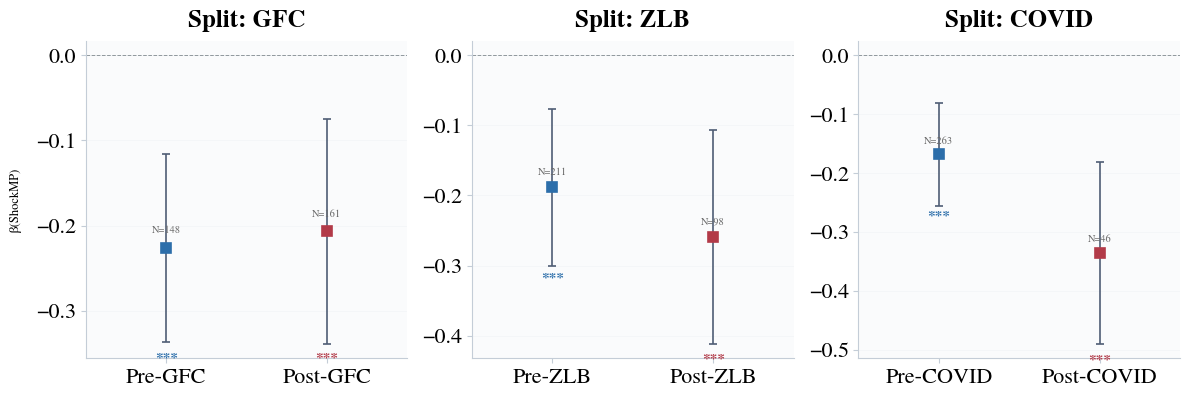

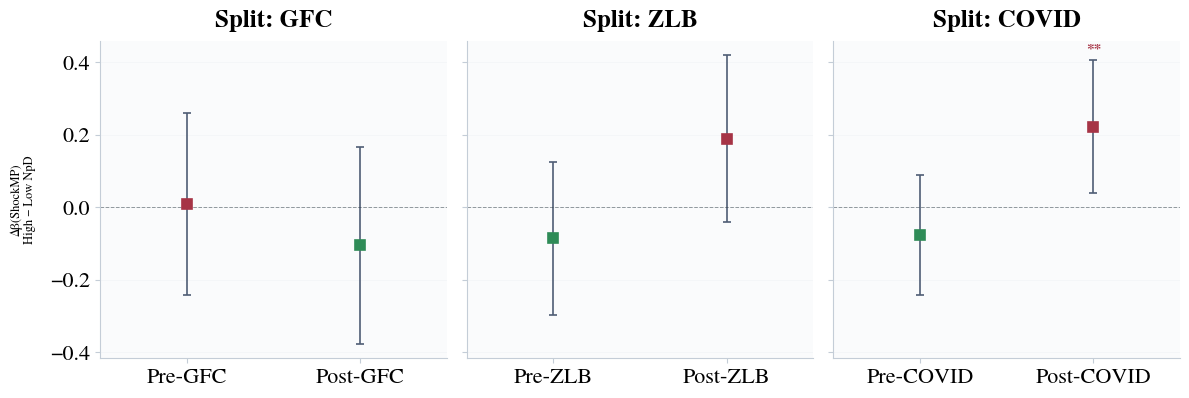

In [23]:
print("=" * 60)
print("EXTENSION A: SUBPERIOD ANALYSIS")
print("=" * 60)

# ---------------------------------------------------------------------------
# A1. Label subperiods
# ---------------------------------------------------------------------------
SUBPERIOD_CUTS = {
    "GFC":   pd.Timestamp("2008-09-15"),
    "ZLB":   pd.Timestamp("2014-01-01"),
    "COVID": pd.Timestamp("2020-03-01"),
}

def label_subperiods(df, cuts=SUBPERIOD_CUTS):
    out = df.copy()
    for name, cut in cuts.items():
        out[f"subperiod_{name}"] = np.where(
            out["event_date"] < cut, f"Pre-{name}", f"Post-{name}"
        )
    return out

analysis_sample = label_subperiods(analysis_sample)


# ---------------------------------------------------------------------------
# A2. Baseline shock regression per subperiod half
# ---------------------------------------------------------------------------
def run_subperiod_baseline(df, split_col, y_col="R_0_1"):
    rows = []
    for period, part in df.groupby(split_col, sort=True):
        work = part.dropna(subset=["ShockMP", "ShockInfo", y_col]).copy()
        if len(work) < 10:
            continue
        X = sm.add_constant(work[["ShockMP", "ShockInfo"]], has_constant="add")
        res = sm.OLS(work[y_col].astype(float), X.astype(float)).fit(cov_type="HC1")
        rows.append({
            "split":           split_col.replace("subperiod_", ""),
            "period":          period,
            "N":               int(res.nobs),
            "coef(ShockMP)":   res.params.get("ShockMP",   np.nan),
            "se(ShockMP)":     res.bse.get("ShockMP",      np.nan),
            "t(ShockMP)":      res.tvalues.get("ShockMP",  np.nan),
            "p(ShockMP)":      res.pvalues.get("ShockMP",  np.nan),
            "coef(ShockInfo)": res.params.get("ShockInfo", np.nan),
            "se(ShockInfo)":   res.bse.get("ShockInfo",    np.nan),
            "t(ShockInfo)":    res.tvalues.get("ShockInfo",np.nan),
            "p(ShockInfo)":    res.pvalues.get("ShockInfo",np.nan),
            "R2":              res.rsquared,
        })
    return pd.DataFrame(rows)

subperiod_baseline_rows = [
    run_subperiod_baseline(analysis_sample, f"subperiod_{name}")
    for name in SUBPERIOD_CUTS
]
subperiod_baseline_table = pd.concat(subperiod_baseline_rows, ignore_index=True)

print("Baseline shock sensitivity by subperiod (R_0_1):")
display(subperiod_baseline_table)


# ---------------------------------------------------------------------------
# A3. Duration median regime split per subperiod half (NpD)
# ---------------------------------------------------------------------------
def run_subperiod_regime(df, split_col,
                         duration_col="D_netpayout_yearly_event",
                         duration_label="NpD", y_col="R_0_1", min_obs=15):
    regime_rows, delta_rows = [], []
    for period, part in df.groupby(split_col, sort=True):
        sub = part.dropna(subset=[duration_col, "ShockMP", "ShockInfo", y_col]).copy()
        if len(sub) < min_obs * 2:
            continue
        med = sub[duration_col].median()
        sub["regime"] = np.where(sub[duration_col] >= med, "High", "Low")
        betas, ses = {}, {}
        for regime, chunk in sub.groupby("regime"):
            if len(chunk) < min_obs:
                continue
            X = sm.add_constant(chunk[["ShockMP", "ShockInfo"]], has_constant="add")
            res = sm.OLS(chunk[y_col].astype(float), X.astype(float)).fit(cov_type="HC1")
            betas[regime] = res.params
            ses[regime] = res.bse
            regime_rows.append({
                "split":          split_col.replace("subperiod_", ""),
                "period":         period,
                "duration":       duration_label,
                "regime":         regime,
                "N":              int(res.nobs),
                "coef(ShockMP)":  res.params.get("ShockMP", np.nan),
                "se(ShockMP)":    res.bse.get("ShockMP",    np.nan),
                "t(ShockMP)":     res.tvalues.get("ShockMP",np.nan),
                "p(ShockMP)":     res.pvalues.get("ShockMP",np.nan),
                "R2":             res.rsquared,
            })
        if "High" in betas and "Low" in betas:
            delta_mp = betas["High"].get("ShockMP", np.nan) - betas["Low"].get("ShockMP", np.nan)
            se_h = ses["High"].get("ShockMP", np.nan)
            se_l = ses["Low"].get("ShockMP", np.nan)
            se_delta = np.sqrt(se_h**2 + se_l**2) if not (np.isnan(se_h) or np.isnan(se_l)) else np.nan
            delta_rows.append({
                "split":       split_col.replace("subperiod_", ""),
                "period":      period,
                "duration":    duration_label,
                "Delta_MP":    delta_mp,
                "se_Delta_MP": se_delta,
            })
    return pd.DataFrame(regime_rows), pd.DataFrame(delta_rows)

all_regime, all_delta = [], []
for name in SUBPERIOD_CUTS:
    r, d = run_subperiod_regime(analysis_sample, f"subperiod_{name}",
                                duration_col="D_netpayout_yearly_event",
                                duration_label="NpD")
    all_regime.append(r)
    all_delta.append(d)

subperiod_regime_table = pd.concat(all_regime, ignore_index=True)
subperiod_delta_table  = pd.concat(all_delta,  ignore_index=True)

print("\nDuration regime split by subperiod (NpD):")
display(subperiod_regime_table)
print("\nHigh-minus-Low Δβ(ShockMP) by subperiod (NpD):")
display(subperiod_delta_table)

subperiod_baseline_table.to_csv(output_dir / "extension_a_subperiod_baseline.csv", index=False)
subperiod_regime_table.to_csv(output_dir / "extension_a_subperiod_regime.csv", index=False)
subperiod_delta_table.to_csv(output_dir / "extension_a_subperiod_delta.csv", index=False)


# ---------------------------------------------------------------------------
# A4. Plots  (marker-based, consistent with Equities notebook)
# ---------------------------------------------------------------------------
from scipy import stats as scipy_stats
set_global_plot_style()

PERIOD_ORDER = {
    "GFC":   ["Pre-GFC",   "Post-GFC"],
    "ZLB":   ["Pre-ZLB",   "Post-ZLB"],
    "COVID": ["Pre-COVID", "Post-COVID"],
}
_split_colors = [COLORS["blue"], COLORS["accent"]]
_marker = _DUR_MARKERS.get("NpD", "s")

# Plot A1: baseline β(ShockMP) across subperiod halves
fig_a1, axes_a1 = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

for ax, split in zip(axes_a1, SUBPERIOD_CUTS):
    sub = (subperiod_baseline_table[subperiod_baseline_table["split"] == split]
           .set_index("period"))
    periods = PERIOD_ORDER[split]
    x = np.arange(len(periods))

    coefs = [float(sub.loc[p, "coef(ShockMP)"]) if p in sub.index else np.nan for p in periods]
    ses   = [float(sub.loc[p, "se(ShockMP)"])   if p in sub.index else np.nan for p in periods]
    pvals = [float(sub.loc[p, "p(ShockMP)"])    if p in sub.index else np.nan for p in periods]
    ns    = [int(sub.loc[p, "N"])               if p in sub.index else 0      for p in periods]

    errs = [1.96 * s if not np.isnan(s) else 0.0 for s in ses]

    for xi, (c, e, col) in enumerate(zip(coefs, errs, _split_colors)):
        if np.isnan(c):
            continue
        ax.errorbar([xi], [c], yerr=[e],
                    fmt=_marker, color=col, markersize=7,
                    markerfacecolor=col, markeredgecolor=col,
                    markeredgewidth=1.2,
                    ecolor=COLORS.get("neutral", "#aaa"),
                    capsize=3, capthick=1.2, linewidth=1.2)
    ax.axhline(0, color=COLORS["reference"], linewidth=0.7, linestyle="--", alpha=0.5)

    for xi, (c, p, e, n) in enumerate(zip(coefs, pvals, errs, ns)):
        if not np.isnan(c):
            _star = significance_stars(p)
            if _star:
                _y_off = c + e + abs(c) * 0.05 if c >= 0 else c - e - abs(c) * 0.05
                ax.text(xi, _y_off, _star, ha="center",
                        va="bottom" if c >= 0 else "top",
                        fontsize=11, color=_split_colors[xi], fontweight="bold")
            ax.text(xi, c - 0.015 * np.sign(c) if c != 0 else -0.01, f"N={n}",
                    ha="center", va="top" if c >= 0 else "bottom",
                    fontsize=7.5, color="dimgray")

    ax.set_xticks(x)
    ax.set_xticklabels(periods, fontsize=8.5)
    ax.set_xlim(-0.5, len(x) - 0.5)
    ax.set_title(f"Split: {split}", fontsize=9.5, fontweight="bold")
    ax.set_ylabel("β(ShockMP)" if split == "GFC" else "", fontsize=9)
    style_axes(ax, grid_axis="y", grid_alpha=0.22)

fig_a1.tight_layout()
save_figure(fig_a1, "subperiod_baseline_shockmp", dpi=300)
plt.show()


# Plot A2: High-minus-Low Δβ(ShockMP) across subperiod halves (NpD only)
_dur_available = ["NpD"]
n_dur_rows = len(_dur_available)

fig_a2, axes_a2 = plt.subplots(n_dur_rows, 3, figsize=(12, 4),
                                sharey="row")
if n_dur_rows == 1:
    axes_a2 = axes_a2[np.newaxis, :]  # ensure 2D

for row_idx, dur_label in enumerate(_dur_available):
    dur_deltas = subperiod_delta_table[subperiod_delta_table["duration"] == dur_label]

    for col_idx, split in enumerate(SUBPERIOD_CUTS):
        ax = axes_a2[row_idx, col_idx]
        sub_d = dur_deltas[dur_deltas["split"] == split]
        periods = PERIOD_ORDER[split]
        deltas_plot, se_plot = [], []
        for p in periods:
            row = sub_d[sub_d["period"] == p]
            deltas_plot.append(float(row["Delta_MP"].iloc[0]) if not row.empty else np.nan)
            se_plot.append(float(row["se_Delta_MP"].iloc[0]) if not row.empty and "se_Delta_MP" in row.columns else np.nan)

        errs = [1.96 * s if not np.isnan(s) else 0.0 for s in se_plot]
        marker_colors = [COLORS.get("green", "#2ca02c") if not np.isnan(v) and v <= 0
                         else COLORS.get("red", "#d62728") for v in deltas_plot]

        x = np.arange(len(periods))
        for xi, (v, e, col) in enumerate(zip(deltas_plot, errs, marker_colors)):
            if np.isnan(v):
                continue
            ax.errorbar([xi], [v], yerr=[e],
                        fmt=_marker, color=col, markersize=7,
                        markerfacecolor=col, markeredgecolor=col,
                        markeredgewidth=1.2,
                        ecolor=COLORS.get("neutral", "#aaa"),
                        capsize=3, capthick=1.2, linewidth=1.2)
        ax.axhline(0, color=COLORS["reference"], linewidth=0.7, linestyle="--", alpha=0.5)

        for xi, (v, se) in enumerate(zip(deltas_plot, se_plot)):
            if not np.isnan(v) and not np.isnan(se) and se > 0:
                _t = abs(v / se)
                _p = 2 * (1 - scipy_stats.norm.cdf(_t))
                _star = significance_stars(_p)
                if _star:
                    _e = 1.96 * se
                    _y_off = v + _e + abs(v) * 0.05 if v >= 0 else v - _e - abs(v) * 0.05
                    ax.text(xi, _y_off, _star, ha="center",
                            va="bottom" if v >= 0 else "top",
                            fontsize=11, color=marker_colors[xi], fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(periods, fontsize=8.5)
        ax.set_xlim(-0.5, len(x) - 0.5)
        if row_idx == 0:
            ax.set_title(f"Split: {split}", fontsize=9.5, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(f"Δβ(ShockMP)\nHigh − Low {dur_label}", fontsize=9)
        style_axes(ax, grid_axis="y", grid_alpha=0.22)

fig_a2.tight_layout()
save_figure(fig_a2, "subperiod_regime_delta", dpi=300)
plt.show()


In [24]:
# ── Subperiod regime LaTeX table ─────────────────────────────────────────
# Compiles `subperiod_delta_table` and `subperiod_regime_table` into a single
# LaTeX table for Section 5.4 of the thesis. Each row reports the High-minus-
# -Low difference in the ShockMP coefficient for one subperiod half, with a
# Welch-type pooled standard error and a normal-approximation p-value.

from scipy import stats as scipy_stats

PERIOD_ORDER_TBL = [
    ("GFC",   "Pre-GFC"),
    ("GFC",   "Post-GFC"),
    ("ZLB",   "Pre-ZLB"),
    ("ZLB",   "Post-ZLB"),
    ("COVID", "Pre-COVID"),
    ("COVID", "Post-COVID"),
]

# Build a per-row record with N_high, N_low, Delta, SE, t, p
_subperiod_rows = []
for split, period in PERIOD_ORDER_TBL:
    delta_match = subperiod_delta_table[
        (subperiod_delta_table["split"] == split) &
        (subperiod_delta_table["period"] == period) &
        (subperiod_delta_table["duration"] == "NpD")
    ]
    if delta_match.empty:
        continue
    drow = delta_match.iloc[0]
    delta = float(drow["Delta_MP"])
    se = float(drow["se_Delta_MP"])

    # Sample sizes per regime
    reg_match = subperiod_regime_table[
        (subperiod_regime_table["split"] == split) &
        (subperiod_regime_table["period"] == period) &
        (subperiod_regime_table["duration"] == "NpD")
    ]
    n_high = int(reg_match[reg_match["regime"] == "High"]["N"].iloc[0]) if not reg_match.empty else np.nan
    n_low  = int(reg_match[reg_match["regime"] == "Low"]["N"].iloc[0])  if not reg_match.empty else np.nan

    # Welch-type t and normal-approx p
    t_stat = delta / se if se > 0 else np.nan
    p_val = 2 * (1 - scipy_stats.norm.cdf(abs(t_stat))) if not np.isnan(t_stat) else np.nan

    _subperiod_rows.append({
        "split":   split,
        "period":  period,
        "N_high":  n_high,
        "N_low":   n_low,
        "delta":   delta,
        "se":      se,
        "t":       t_stat,
        "p":       p_val,
    })

subperiod_table_summary = pd.DataFrame(_subperiod_rows)
subperiod_table_summary.to_csv(
    output_dir / "extension_a_subperiod_summary.csv", index=False
)
print("Subperiod summary table:")
display(subperiod_table_summary)


# ── LaTeX writer ─────────────────────────────────────────────────────────

def _fmt_delta_with_stars(delta, p):
    """Negative-aware formatter with significance stars."""
    if pd.isna(delta):
        return ""
    stars = _tex_stars(p) if not pd.isna(p) else ""
    if delta >= 0:
        body = r"\phantom{-}" + f"{delta:.4f}"
    else:
        body = f"{delta:.4f}"
    return f"${body}${stars}"


_L = []
_L.append(r"\begin{table}[htbp]")
_L.append(r"\centering\small")
_L.append(r"\caption{\textsc{Index-Level Duration Regime Effect by Subperiod}}")
_L.append(r"\label{tab:index_subperiod}")
_L.append(r"\begin{tabular}{llcccc}")
_L.append(r"\toprule")
_L.append(
    r"Split & Period & $\Delta\beta_{\text{MP}}$ "
    r"& SE & $t$ & $N_{\text{High}}/N_{\text{Low}}$ \\"
)
_L.append(r"\midrule")

# Group rows by split with a small visual separator
_prev_split = None
for _, row in subperiod_table_summary.iterrows():
    if _prev_split is not None and row["split"] != _prev_split:
        _L.append(r"\addlinespace[2pt]")
    _delta_str = _fmt_delta_with_stars(row["delta"], row["p"])
    _se_str    = f"{row['se']:.4f}" if pd.notna(row["se"]) else ""
    _t_str     = f"${row['t']:.2f}$" if pd.notna(row["t"]) else "--"
    _n_str     = f"{int(row['N_high'])}/{int(row['N_low'])}" if pd.notna(row["N_high"]) else ""
    _L.append(
        f"{row['split']} & {row['period']} & {_delta_str} & "
        f"{_se_str} & {_t_str} & {_n_str} \\\\"
    )
    _prev_split = row["split"]

_L.append(r"\bottomrule")
_L.append(r"\end{tabular}")
_L.append("")
_L.append(r"\vspace{4pt}")
_L.append(r"\begin{minipage}{\textwidth}")
_L.append(r"\footnotesize")
_L.append(
    r"\textit{Notes.} Each row reports the High-minus-Low difference "
    r"$\Delta\beta_{\text{MP}} \equiv \beta_{\text{MP}}^{\text{High}} - "
    r"\beta_{\text{MP}}^{\text{Low}}$ in the regression of the two-day "
    r"Euro\,500 return $R_{0,1}$ on $\text{ShockMP}$ and $\text{ShockInfo}$, "
    r"estimated separately within each subperiod half and within the high- "
    r"and low-NpD regimes (median split on $\bar{D}_{y(t)-1}$). "
    r"The Welch-type pooled standard error treats the two regime samples as "
    r"independent. Subperiod cuts: GFC $=$ 15 September 2008, ZLB $=$ 1 "
    r"January 2014, COVID $=$ 1 March 2020. $p$-values from the two-sided "
    r"normal approximation. $^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$."
)
_L.append(r"\end{minipage}")
_L.append(r"\end{table}")

_tex_subperiod = "\n".join(_L)
_out_subperiod = output_dir / "tab_index_subperiod.tex"
_out_subperiod.write_text(_tex_subperiod, encoding="utf-8")
print(f"\nSaved: {_out_subperiod}")
print()
print("--- Preview: tab_index_subperiod.tex (first 1800 chars) ---")
print(_tex_subperiod[:1800])


Subperiod summary table:


,split,period,N_high,N_low,delta,se,t,p
0,GFC,Pre-GFC,79,69,0.009257,0.128505,0.072039,0.942571
1,GFC,Post-GFC,83,78,-0.105046,0.138734,-0.757177,0.448944
2,ZLB,Pre-ZLB,115,96,-0.085641,0.107114,-0.799531,0.423982
3,ZLB,Post-ZLB,56,42,0.189500,0.117242,1.616313,0.106027
4,COVID,Pre-COVID,139,124,-0.075467,0.084664,-0.891370,0.372731
5,COVID,Post-COVID,23,23,0.222132,0.093388,2.378584,0.017379



Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/ECBShocks_Index_Regressions/tab_index_subperiod.tex

--- Preview: tab_index_subperiod.tex (first 1800 chars) ---
\begin{table}[htbp]
\centering\small
\caption{\textsc{Index-Level Duration Regime Effect by Subperiod}}
\label{tab:index_subperiod}
\begin{tabular}{llcccc}
\toprule
Split & Period & $\Delta\beta_{\text{MP}}$ & SE & $t$ & $N_{\text{High}}/N_{\text{Low}}$ \\
\midrule
GFC & Pre-GFC & $\phantom{-}0.0093$ & 0.1285 & $0.07$ & 79/69 \\
GFC & Post-GFC & $-0.1050$ & 0.1387 & $-0.76$ & 83/78 \\
\addlinespace[2pt]
ZLB & Pre-ZLB & $-0.0856$ & 0.1071 & $-0.80$ & 115/96 \\
ZLB & Post-ZLB & $\phantom{-}0.1895$ & 0.1172 & $1.62$ & 56/42 \\
\addlinespace[2pt]
COVID & Pre-COVID & $-0.0755$ & 0.0847 & $-0.89$ & 139/124 \\
COVID & Post-COVID & $\phantom{-}0.2221$$^{**}$ & 0.0934 & $2.38$ & 23/23 \\
\bottomrule
\end{tabular}

\vspace{4pt}
\begin{minipage}{\textwidth}
\footnotesize
\textit{Notes

In [25]:
baseline_full_table.to_csv(output_dir / "index_regression_baseline_full_sample.csv", index=False)
baseline_large_shock_table.to_csv(output_dir / "index_regression_baseline_large_shocks.csv", index=False)
regime_results_full.to_csv(output_dir / "index_regression_regimes_full_sample.csv", index=False)
regime_differences_full.to_csv(output_dir / "index_regression_regime_deltas_full_sample.csv", index=False)
regime_results_large_shocks.to_csv(output_dir / "index_regression_regimes_large_shocks.csv", index=False)
regime_differences_large_shocks.to_csv(output_dir / "index_regression_regime_deltas_large_shocks.csv", index=False)

print("Saved baseline and regime outputs to the output directory.")


Saved baseline and regime outputs to the output directory.


## 13. Save outputs

The final section writes the key datasets and regression tables to disk so they can be reused in the thesis text, appendix tables, or later robustness work.


### Duration-Measure Diagnostics

The following diagnostics report distributional properties of both market-
duration measures for completeness. NpD is the primary measure throughout;
FcstD is included here to document its basic properties and is used in
the regressions only as the robustness check in the FcstD section above.


In [26]:
# ── Duration-measure diagnostics ─────────────────────────────────────────────
# Distributional properties of both market-duration series.
# NpD is the primary measure; FcstD is reported here for context and is
# used in the regressions only as the dedicated robustness check above.

def diagnostic_summary_table(duration_df):
    stats = ["mean", "std", "min", "median", "max"]
    summary = pd.DataFrame({"statistic": stats})
    for col, label in [
        ("market_duration_netpayout", "NpD"),
        ("market_duration_fcstd",     "FcstD"),
    ]:
        summary[label] = [
            duration_df[col].mean(),
            duration_df[col].std(),
            duration_df[col].min(),
            duration_df[col].median(),
            duration_df[col].max(),
        ]
    return summary


duration_diagnostics = diagnostic_summary_table(market_duration_yearly)
duration_correlation = market_duration_yearly[
    ["market_duration_netpayout", "market_duration_fcstd"]
].corr()

coverage_summary = pd.DataFrame({
    "metric": [
        "Average firms (NpD)",
        "Average firms (FcstD)",
        "Average coverage (NpD)",
        "Average coverage (FcstD)",
        "First year (NpD)",
        "First year (FcstD)",
    ],
    "value": [
        market_duration_yearly["n_firms_netpayout"].mean(),
        market_duration_yearly["n_firms_fcstd"].mean(),
        market_duration_yearly["coverage_netpayout"].mean(),
        market_duration_yearly["coverage_fcstd"].mean(),
        int(market_duration_yearly.loc[
            market_duration_yearly["market_duration_netpayout"].notna(), "year"].min()),
        int(market_duration_yearly.loc[
            market_duration_yearly["market_duration_fcstd"].notna(), "year"].min()),
    ],
})

# Top/bottom NpD years (primary measure).
top_high_years = market_duration_yearly[[
    "year", "market_duration_netpayout", "market_duration_fcstd"
]].sort_values("market_duration_netpayout", ascending=False).head(10)
top_low_years = market_duration_yearly[[
    "year", "market_duration_netpayout", "market_duration_fcstd"
]].sort_values("market_duration_netpayout", ascending=True).head(10)

print("Summary statistics: annual market duration (NpD primary, FcstD for context)")
display(duration_diagnostics)
print("Cross-measure correlation")
display(duration_correlation)
print("Coverage and firm-count summary")
display(coverage_summary)
print("Top 10 highest-NpD years")
display(top_high_years)
print("Top 10 lowest-NpD years")
display(top_low_years)

# ── CSV exports ──────────────────────────────────────────────────────────────
market_duration_yearly.to_csv(output_dir / "market_duration_yearly.csv", index=False)
event_dataset.to_csv(output_dir / "ecb_index_event_dataset.csv", index=False)

results_export = pd.concat([
    results_main.assign(result_set="main"),
    results_raw_duration.assign(result_set="raw_duration"),
    results_large_shocks.assign(result_set="large_shocks"),
    results_hac.assign(result_set="hac"),
    results_fcstd.assign(result_set="fcstd_robustness"),
], ignore_index=True)
results_export.to_csv(output_dir / "index_regression_results_main.csv", index=False)

TABLE_3.to_csv(output_dir / "index_regression_results_reader.csv", index=False)
TABLE_1.to_latex(output_dir / "index_regression_results_main.tex",
                 index=False, float_format="%.4f")

print(f"Saved outputs to: {output_dir.resolve()}")


Summary statistics: annual market duration (NpD primary, FcstD for context)


,statistic,NpD,FcstD
0,mean,24.406566,25.138787
1,std,1.741625,2.426997
2,min,22.701843,21.327896
3,median,23.744831,25.260255
4,max,30.058233,31.321623


Cross-measure correlation


,market_duration_netpayout,market_duration_fcstd
market_duration_netpayout,1.000000,0.696076
market_duration_fcstd,0.696076,1.000000


Coverage and firm-count summary


...

Top 10 highest-NpD years


,year,market_duration_netpayout,market_duration_fcstd
2,1999,30.058233,31.095808
3,2000,27.550159,28.896746
1,1998,27.166243,31.321623
8,2005,26.118725,24.782673
4,2001,26.053296,23.909470
5,2002,25.533181,26.700346
6,2003,25.488998,21.665690
7,2004,25.482574,26.438040
9,2006,24.850867,23.828349
10,2007,24.617848,26.135219


Top 10 lowest-NpD years


,year,market_duration_netpayout,market_duration_fcstd
13,2010,22.701843,25.260255
26,2023,22.759288,21.922787
25,2022,22.842721,21.327896
14,2011,22.975199,23.972749
22,2019,23.001376,25.492888
15,2012,23.012169,24.661937
27,2024,23.141013,22.231472
16,2013,23.192406,25.542263
17,2014,23.222966,24.949493
21,2018,23.336375,24.276293


Saved outputs to: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/ECBShocks_Index_Regressions


## Interpretation Notes

**Headline results (Model 1, NpD, value-weighted, HC1 SEs, $R_{0,1}$)**

- $\text{ShockMP} \times \text{NpD}$: $-0.0315$ ($t = -1.00$).
- $\text{ShockInfo} \times \text{NpD}$: $+0.0194$ ($t = +0.65$).
- High-minus-Low duration regime difference in $\text{ShockMP}$ (median split): $-0.0832$ ($p = 0.37$), directional but not significant at conventional levels. Under tighter thresholds that drop the middle portion of the duration distribution, the difference widens and becomes significant: $-0.1771$ at P33/P67 ($p = 0.04$) and $-0.1833$ at P25/P75 ($p = 0.03$). The dose-response pattern across thresholds is the informative evidence, not any single split. The regime effect is therefore meaningful in the tails of the duration distribution rather than uniform across the full sample.

**How to read the index-level results**

- The continuous $\text{ShockMP} \times \text{NpD}$ interaction is smaller in absolute size and weaker in significance than its firm-level counterpart. This is expected. The firm-level interaction is identified from cross-firm dispersion in NpD on each event date; the index-level interaction is identified from gradual time-series variation in aggregate duration. Aggregation collapses the cross-sectional signal into a single time series and substantially reduces identifying power.
- The regime-split design ("12A" in this notebook) recovers more of the economic content by contrasting average $\text{ShockMP}$ sensitivity in high-duration versus low-duration market states. This produces the largest and most stable estimates in the index-level analysis. The resulting evidence is consistent with the duration channel but, in isolation from the firm-level cross-sectional design, cannot rule out overlapping debt-maturity or refinancing mechanisms that may load onto the same regressor.
- The four robustness checks (R1–R4) all preserve the sign and approximate magnitude of the High-minus-Low difference: first differences in market duration, rolling 5-year windows, alternative regime thresholds, and lagged duration. The summary appears in `tab_index_robustness_summary.tex`.

**FcstD as robustness (Robustness 5)**

At the firm level, FcstD yields substantially weaker interaction coefficients than NpD (Section 5.3 and Appendix B.6 of the thesis): approximately 71\% of the FcstD present value sits in the post-year-30 terminal component, and the industry-ROE reversion compresses cross-sectional variation so that FcstD behaves largely as a book-to-market proxy across firms.

At the aggregate level this picture changes. Both the NpD and FcstD market-duration series track the same compositional drift of the Euro\,500 portfolio over time, so the two aggregates are highly correlated, and they produce interaction coefficients of similar magnitude. In this notebook, $\text{ShockMP} \times \text{FcstD} = -0.0524$ ($t = -1.38$) on $R_{0,1}$, compared with $\text{ShockMP} \times \text{NpD} = -0.0315$ ($t = -1.00$). Both fall short of conventional significance — the structural weakness of linear interactions at the index level (see Section 12 and the identification discussion above) applies to both measures. The FcstD-only robustness regression (`tab_index_fcstd_robustness.tex`) is reported as a parallel specification rather than a weakened benchmark; its purpose is to confirm that the headline pattern is not an artefact of the specific duration measure.

**Subperiod evidence (Extension A)**

The subperiod analysis splits the sample at three structural break dates (Pre/Post GFC, Pre/Post ZLB, Pre/Post COVID). The High-minus-Low duration difference is essentially zero in the pre-GFC subperiod and becomes economically meaningful in the post-crisis subperiods. Formal significance is clear in the post-GFC and post-COVID splits; post-ZLB is only marginal ($p \approx 0.09$ by normal approximation). The overall pattern is consistent with the interpretation in the thesis that equity duration sensitivity is a phenomenon of the post-crisis, low-rate macro regime, where the discount-rate channel dominates and aggregate composition shifts more sharply between long- and short-duration tilts, but no single subperiod should be read as conclusive.

**Reading the headline coefficients**

- A negative $\text{ShockMP} \times \text{NpD}$ coefficient at the index level says: when the Euro\,500 portfolio is tilted toward longer-duration constituents, the aggregate index suffers a larger loss in response to a contractionary monetary policy surprise.
- The High-minus-Low regime difference says the same thing in discrete form: events occurring in high-duration market states have a more negative average $\text{ShockMP}$ slope than events occurring in low-duration states.

**Limitations**

- Only one return observation per event date means HC1 (or HAC) standard errors, not clustering, are the appropriate inference.
- The sample of 309 ECB events is large by event-study standards but small for a continuous time-series interaction; the regime design is preferred for this reason.
- The aggregate measure does not separate the equity discount-rate channel from a debt-refinancing channel that may also generate cyclicality in the index-level shock response.
